# Customer Profitability and Behavioral Segmentation Using Unsupervised Machine Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D   

FILE_PATH = "samplesuperstore.csv"    
RANDOM_STATE = 42                     
K_RANGE = list(range(2, 9))            
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded. Random state =", RANDOM_STATE)

Libraries loaded. Random state = 42


# Load the data

In [2]:
try:
    raw = pd.read_csv(FILE_PATH, encoding="utf-8")
    print("Loaded with utf-8 encoding")
except UnicodeDecodeError:
    raw = pd.read_csv(FILE_PATH, encoding="cp1252")
    print("utf-8 failed, loaded with cp1252 instead")


required_columns = ["Row ID", "Order ID", "Order Date", "Ship Date", "Customer ID", "Customer Name",
                    "Segment", "Product ID", "Sales", "Quantity", "Discount", "Profit"]
missing_required = [c for c in required_columns if c not in raw.columns]
assert not missing_required, f"Required columns missing from your file: {missing_required}"

print("Shape (rows, columns):", raw.shape)
raw.head()

Loaded with utf-8 encoding
Shape (rows, columns): (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.200,5.551
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.800,-5.487
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.200,4.272
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.200,-64.775
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.200,4.884


In [3]:
raw.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10189,10190,US-2026-143259,12/30/2026,1/3/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.200,19.791
10190,10191,US-2026-115427,12/30/2026,1/3/2027,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.200,6.475
10191,10192,US-2026-156720,12/30/2026,1/3/2027,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.200,-0.605
10192,10193,US-2026-143259,12/30/2026,1/3/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.000,2.728
10193,10194,CA-2026-143500,12/30/2026,1/3/2027,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,Prince Edward Island,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.200,-0.605


In [4]:
print("Columns:", list(raw.columns))
print()
raw.dtypes.to_frame("dtype")

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']



,dtype
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object


**How to read the output.** After running the two cells above, check: (1) are `Order Date` and `Ship Date` stored as text (they need parsing)? (2) is `Postal Code` stored as text or as a number? A postal code is a *label*, not a quantity, so it must never be treated as a continuous variable. (3) Do any column names differ from the standard Superstore file (for example `Country/Region`, `State/Province`)? We handle those in Section 4.

# Missing values and duplicate records

In [5]:
print("Total missing values in the whole table:", int(raw.isna().sum().sum()))
display(raw.isna().sum().to_frame("missing").T)

cols_without_row_id = [c for c in raw.columns if c != "Row ID"]
print("Fully duplicated rows                      :", int(raw.duplicated().sum()))
print("Duplicated Row IDs                          :", int(raw["Row ID"].duplicated().sum()))
print("Rows identical in EVERY column except Row ID:", int(raw.duplicated(subset=cols_without_row_id).sum()))
print("Repeated (Order ID, Product ID) combinations:", int(raw.duplicated(subset=["Order ID", "Product ID"]).sum()))

Total missing values in the whole table: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Fully duplicated rows                      : 0
Duplicated Row IDs                          : 0
Rows identical in EVERY column except Row ID: 2
Repeated (Order ID, Product ID) combinations: 11


# Unique values

In [6]:
id_columns = ["Row ID", "Order ID", "Customer ID", "Customer Name", "Product ID", "Product Name"]
id_columns = [c for c in id_columns if c in raw.columns]
unique_counts = pd.DataFrame({"unique_values": [raw[c].nunique() for c in id_columns]}, index=id_columns)
display(unique_counts)

print("Transaction rows:", len(raw))
print("Average line items per order   :", round(len(raw) / raw["Order ID"].nunique(), 2))
print("Average line items per customer:", round(len(raw) / raw["Customer ID"].nunique(), 2))

,unique_values
Row ID,10194
Order ID,5111
Customer ID,804
Customer Name,800
Product ID,1862
Product Name,1849


Transaction rows: 10194
Average line items per order   : 1.99
Average line items per customer: 12.68


In [7]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]
display(raw[numeric_columns].describe().T)

print("Distinct Discount values (it is a discrete, tiered variable):")
display(raw["Discount"].value_counts().sort_index().to_frame("rows"))
print("Share of rows with Profit < 0:", round((raw["Profit"] < 0).mean(), 4))

,count,mean,std,min,25%,50%,75%,max
Sales,"10,194.000",228.226,619.907,0.444,17.220,53.910,209.500,"22,638.480"
Quantity,"10,194.000",3.792,2.228,1.000,2.000,3.000,5.000,14.000
Discount,"10,194.000",0.155,0.206,0.000,0.000,0.200,0.200,0.800
Profit,"10,194.000",28.673,232.465,"-6,599.978",1.761,8.690,29.298,"8,399.976"


Distinct Discount values (it is a discrete, tiered variable):


,rows
Discount,
0.000,4925
0.100,96
0.150,52
0.200,3706
0.300,230
0.320,27
0.400,207
0.450,11
0.500,66


Share of rows with Profit < 0: 0.1865


In [8]:
categorical_columns = [c for c in ["Segment", "Region", "Country/Region", "Country", "Category", "Sub-Category", "Ship Mode"]
                       if c in raw.columns]
for col in categorical_columns:
    print(f"--- {col} ({raw[col].nunique()} levels) ---")
    display(raw[col].value_counts().to_frame("rows").T)

--- Segment (3 levels) ---


Segment,Consumer,Corporate,Home Office
rows,5281,3090,1823


--- Region (4 levels) ---


Region,West,East,Central,South
rows,3253,2986,2335,1620


--- Country/Region (2 levels) ---


...

Category,Office Supplies,Furniture,Technology
rows,6128,2201,1865


--- Sub-Category (17 levels) ---


Sub-Category,Binders,Paper,Furnishings,Phones,Storage,Art,Accessories,Chairs,Appliances,Labels,Tables,Envelopes,Bookcases,Fasteners,Supplies,Machines,Copiers
rows,1548,1384,1009,903,856,821,775,634,474,368,326,256,232,229,192,117,70


--- Ship Mode (4 levels) ---


Ship Mode,Standard Class,Second Class,First Class,Same Day
rows,6120,1979,1548,547


# Preprocessing 

In [9]:
df = raw.copy()

df = df.rename(columns={"Country/Region": "Country", "State/Province": "State"})

# Parse dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

if "Postal Code" in df.columns:
    df["Postal Code"] = df["Postal Code"].astype(str)

print("Cleaned shape:", df.shape)
print("Order Date range:", df["Order Date"].min().date(), "->", df["Order Date"].max().date())

Cleaned shape: (10194, 21)
Order Date range: 2023-01-03 -> 2026-12-30


In [10]:
checks = {
    "Sales <= 0": int((df["Sales"] <= 0).sum()),
    "Quantity <= 0": int((df["Quantity"] <= 0).sum()),
    "Discount outside [0, 1]": int((~df["Discount"].between(0, 1)).sum()),
    "Ship Date before Order Date": int((df["Ship Date"] < df["Order Date"]).sum()),
    "Missing Order Date or Ship Date": int(df[["Order Date", "Ship Date"]].isna().sum().sum()),
    "Profit greater than Sales (impossible if costs >= 0)": int((df["Profit"] > df["Sales"]).sum()),
}
pd.Series(checks, name="rows affected").to_frame()

,rows affected
Sales <= 0,0
Quantity <= 0,0
"Discount outside [0, 1]",0
Ship Date before Order Date,0
Missing Order Date or Ship Date,0
Profit greater than Sales (impossible if costs >= 0),0


In [11]:
cols_without_row_id = [c for c in df.columns if c != "Row ID"]

all_copies = df[df.duplicated(subset=cols_without_row_id, keep=False)].sort_values(["Order ID", "Product ID", "Row ID"])
print("Rows involved in suspected duplicate pairs:", len(all_copies))
display(all_copies[["Row ID", "Order ID", "Customer ID", "Order Date", "Product ID", "Sales", "Quantity", "Discount", "Profit"]])


rows_to_remove = df.duplicated(subset=cols_without_row_id, keep="first")
df_dedup = df[~rows_to_remove].copy()
print(f"\nPRIMARY data keeps all {len(df):,} rows. df_dedup (used ONLY in Section 24) has {len(df_dedup):,} rows.")

other_repeats = df[df.duplicated(subset=["Order ID", "Product ID"], keep=False)
                   & ~df.duplicated(subset=cols_without_row_id, keep=False)]
print("Rows in repeated (Order ID, Product ID) pairs that differ in quantity/sales (probably legitimate split lines):", len(other_repeats))

Rows involved in suspected duplicate pairs: 4


,Row ID,Order ID,Customer ID,Order Date,Product ID,Sales,Quantity,Discount,Profit
1698,1699,CA-2023-153623,JP-11135,2023-11-24,FUR-FU-10002501,99.120,8,0.000,35.414
1699,1700,CA-2023-153623,JP-11135,2023-11-24,FUR-FU-10002501,99.120,8,0.000,35.414
390,391,US-2023-150119,LB-16795,2023-04-23,FUR-CH-10002965,281.372,2,0.300,-12.059
391,392,US-2023-150119,LB-16795,2023-04-23,FUR-CH-10002965,281.372,2,0.300,-12.059



PRIMARY data keeps all 10,194 rows. df_dedup (used ONLY in Section 24) has 10,192 rows.
Rows in repeated (Order ID, Product ID) pairs that differ in quantity/sales (probably legitimate split lines): 18


In [12]:
today = pd.Timestamp.today().normalize()

# Keep only today's and past orders
df = df[df["Order Date"] <= today].copy()

In [13]:
print("Latest Order Date:", df["Order Date"].max().date())
print("Rows remaining:", len(df))

Latest Order Date: 2026-09-30
Rows remaining: 8943


**How to read the output.** A real transaction cannot be dated in the future, so a non-zero count is a signal that this file is a **teaching/sample dataset with shifted dates**. We keep these rows (dropping them would remove the most recent behavior and change every customer's recency), and we define *recency relative to the dataset's own last order date*, not relative to the real calendar. This is documented as a limitation in Section 27.

In [14]:
# --- Customer Name / Customer ID / Order ID consistency ---
ids_per_name = df.groupby("Customer Name")["Customer ID"].nunique()
names_per_id = df.groupby("Customer ID")["Customer Name"].nunique()
customers_per_order = df.groupby("Order ID")["Customer ID"].nunique()

print("Distinct Customer IDs :", df["Customer ID"].nunique())
print("Distinct Customer Names:", df["Customer Name"].nunique())
print("Names that map to more than one Customer ID :", int((ids_per_name > 1).sum()))
print("IDs that map to more than one Customer Name :", int((names_per_id > 1).sum()))
print("Order IDs that contain more than one Customer ID:", int((customers_per_order > 1).sum()))

geo_cols = [c for c in ["Country", "State"] if c in df.columns]

multi_id_names = ids_per_name[ids_per_name > 1].index
if len(multi_id_names) > 0:
    print("\nNames attached to several Customer IDs:")
    display(df[df["Customer Name"].isin(multi_id_names)][["Customer ID", "Customer Name"] + geo_cols].drop_duplicates())

shared_orders = customers_per_order[customers_per_order > 1].index
if len(shared_orders) > 0:
    print("\nOrder IDs shared by several Customer IDs:")
    display(df[df["Order ID"].isin(shared_orders)][["Order ID", "Customer ID", "Customer Name", "Order Date", "Product ID", "Sales"]]
            .sort_values(["Order ID", "Customer ID"]))

Distinct Customer IDs : 801
Distinct Customer Names: 797
Names that map to more than one Customer ID : 1
IDs that map to more than one Customer Name : 0
Order IDs that contain more than one Customer ID: 2

Names attached to several Customer IDs:


,Customer ID,Customer Name,Country,State
2036,HO-15230,Harry Olson,Canada,Prince Edward Island
5009,HO-15234,Harry Olson,Canada,Prince Edward Island
5010,HO-15233,Harry Olson,Canada,Prince Edward Island
5011,HO-15232,Harry Olson,Canada,Prince Edward Island
5012,HO-15231,Harry Olson,Canada,Prince Edward Island



Order IDs shared by several Customer IDs:


,Order ID,Customer ID,Customer Name,Order Date,Product ID,Sales
5012,CA-2025-121465,HO-15231,Harry Olson,2025-06-12,OFF-BI-10002414,310.120
5011,CA-2025-121465,HO-15232,Harry Olson,2025-06-12,OFF-AR-10003696,70.464
5010,CA-2025-121465,HO-15233,Harry Olson,2025-06-12,FUR-CH-10004495,19.680
5009,CA-2025-121465,HO-15234,Harry Olson,2025-06-12,FUR-CH-10001270,140.670
7194,CA-2026-130494,HO-15231,Harry Olson,2026-03-16,OFF-BI-10002414,310.120
7193,CA-2026-130494,HO-15232,Harry Olson,2026-03-16,OFF-AR-10003696,70.464
7192,CA-2026-130494,HO-15233,Harry Olson,2026-03-16,FUR-CH-10004495,19.680
7191,CA-2026-130494,HO-15234,Harry Olson,2026-03-16,FUR-CH-10001270,140.670


**How to read the output.** In real business data one order belongs to one buyer, and one person normally has one ID. If names map to several IDs, or one Order ID appears under several Customer IDs, the file contains **synthetic or inconsistent identifiers**. Our decision: **`Customer ID` is the customer key**. We do not merge IDs (we have no external evidence that they are the same person) and we do not delete rows. Because we aggregate *by Customer ID*, each ID's own rows are still summed correctly; the anomaly only means we must not make statements such as "there are exactly N distinct real-world orders".

In [15]:
# --- Which attributes are constant within a customer? (decides what may be used to DESCRIBE customers) ---
n_customers_raw = df["Customer ID"].nunique()
for col in ["Segment", "Region", "Country"]:
    if col in df.columns:
        n_multi = int((df.groupby("Customer ID")[col].nunique() > 1).sum())
        print(f"Customers with more than one {col:8s}: {n_multi} of {n_customers_raw}")

Customers with more than one Segment : 0 of 801
Customers with more than one Region  : 742 of 801
Customers with more than one Country : 26 of 801


**How to read the output.** An attribute can describe a *customer* only if it is (nearly) constant for that customer. `Segment` should be constant, so it is a valid profiling variable. If `Region` (or `Country`) varies for most customers, it describes **shipping destinations of individual orders**, not the customer, so it is excluded from both clustering and profiling.

### Section 4 decision log

* Types corrected; nothing deleted.
* Suspected duplicate line pairs: **kept** in the primary analysis; removal is a **sensitivity check** (Section 24).
* Future-dated rows and identifier anomalies: **documented and retained**.
* `Customer ID` is the customer key; `Segment` is a valid descriptive attribute; `Region`/`Country`/`Postal Code`/`City` are not customer attributes and are excluded from the clustering feature set.

---
## 5. Customer-Level Aggregation

**What / why:** clustering transaction rows would treat "customer A bought a stapler" and "customer A bought a conference table" as unrelated observations. Our question is about *customers*, so we collapse the data to **one row per `Customer ID`**.

**Concept:** aggregation changes the unit of analysis. Sums (`total_sales`, `total_profit`, `total_quantity`) describe *size*; ratios (`profit_margin`, `avg_order_value`) describe *rates*; date differences describe *timing*.

**Reference date for recency.** `recency_days = reference_date - last_order_date`. We use the **dataset's own maximum Order Date** as `reference_date`, not today's date, because (a) the file contains orders dated after today (Section 4), and (b) recency must be measured on the same clock as the data. This makes recency a *relative* measure within this data extract.

**Formulas used**

| Variable | Formula |
|---|---|
| `total_sales` | sum of `Sales` |
| `total_profit` | sum of `Profit` |
| `total_quantity` | sum of `Quantity` |
| `n_orders` | number of **unique** `Order ID` |
| `n_line_items` | number of transaction rows |
| `avg_discount` | simple mean of `Discount` over the customer's rows |
| `weighted_discount` | $\sum(\text{Discount}\times\text{Sales}) / \sum \text{Sales}$ |
| `first_order_date`, `last_order_date` | min and max of `Order Date` |

The function below is defined once so that the *same* steps can be re-used for the duplicate-row sensitivity check in Section 24.

In [16]:
def aggregate_customers(data, reference_date):
    """Turn transaction rows into ONE ROW PER CUSTOMER ID (aggregation + derived features)."""
    work = data.copy()

    # helper column so that a sales-weighted discount can be built with a plain groupby-sum
    work["discount_times_sales"] = work["Discount"] * work["Sales"]

    # ---- Step 1: aggregation (groupby + agg) ----
    cust = work.groupby("Customer ID").agg(
        customer_name=("Customer Name", "first"),
        segment=("Segment", "first"),
        total_sales=("Sales", "sum"),
        total_profit=("Profit", "sum"),
        total_quantity=("Quantity", "sum"),
        n_orders=("Order ID", "nunique"),
        n_line_items=("Row ID", "count"),
        avg_discount=("Discount", "mean"),
        discount_times_sales_sum=("discount_times_sales", "sum"),
        first_order_date=("Order Date", "min"),
        last_order_date=("Order Date", "max"),
    ).reset_index()

    # ---- Step 2: derived (engineered) features ----
    # .where(condition) turns values that fail the condition into NaN, so a zero denominator gives NaN, never a fake number
    positive_sales = cust["total_sales"].where(cust["total_sales"] > 0)
    cust["profit_margin"] = cust["total_profit"] / positive_sales
    cust["weighted_discount"] = cust["discount_times_sales_sum"] / positive_sales
    cust["avg_order_value"] = cust["total_sales"] / cust["n_orders"]
    cust["avg_profit_per_order"] = cust["total_profit"] / cust["n_orders"]
    cust["avg_profit_per_line"] = cust["total_profit"] / cust["n_line_items"]
    cust["tenure_days"] = (cust["last_order_date"] - cust["first_order_date"]).dt.days
    cust["recency_days"] = (reference_date - cust["last_order_date"]).dt.days

    # descriptive only (NOT a clustering feature): undefined (NaN) when tenure is 0 days
    positive_tenure = cust["tenure_days"].where(cust["tenure_days"] > 0)
    cust["orders_per_30_days"] = cust["n_orders"] / positive_tenure * 30

    return cust.drop(columns=["discount_times_sales_sum"])


REFERENCE_DATE = df["Order Date"].max()
print("Reference date for recency (dataset's last order date):", REFERENCE_DATE.date())

customers = aggregate_customers(df, REFERENCE_DATE)     # PRIMARY customer table (all rows kept)
assert len(customers) == df["Customer ID"].nunique(), "Aggregation should give one row per Customer ID"

print("Customer-level table shape:", customers.shape)
customers.head()

Reference date for recency (dataset's last order date): 2026-09-30
Customer-level table shape: (801, 19)


,Customer ID,customer_name,segment,total_sales,total_profit,total_quantity,n_orders,n_line_items,avg_discount,first_order_date,last_order_date,profit_margin,weighted_discount,avg_order_value,avg_profit_per_order,avg_profit_per_line,tenure_days,recency_days,orders_per_30_days
0,AA-10315,Alex Avila,Consumer,"5,563.560",-362.883,30,5,11,0.091,2023-03-31,2026-06-29,-0.065,0.183,"1,112.712",-72.577,-32.989,1186,93,0.126
1,AA-10375,Allen Armold,Consumer,906.518,235.018,35,8,12,0.083,2023-04-21,2026-09-07,0.259,0.035,113.315,29.377,19.585,1235,23,0.194
2,AA-10480,Andrew Allen,Consumer,"1,790.512",435.827,36,4,12,0.017,2023-05-04,2026-04-15,0.243,0.002,447.628,108.957,36.319,1077,168,0.111
3,AA-10645,Anna Andreadi,Consumer,"5,073.975",851.583,62,5,17,0.068,2023-06-22,2025-09-04,0.168,0.105,"1,014.795",170.317,50.093,805,391,0.186
4,AB-10015,Aaron Bergman,Consumer,886.156,129.347,13,3,6,0.067,2023-02-18,2025-11-10,0.146,0.014,295.385,43.116,21.558,996,324,0.090


**How to read the output.** The number of rows must equal the number of distinct `Customer ID`s from Section 3 (the `assert` line stops the notebook otherwise). Each row now summarises a customer's *entire observed history*. `orders_per_30_days` is only for description and is `NaN` for customers whose tenure is 0 days; it is **excluded from clustering** because it is a function of `n_orders` and `tenure_days`, which we keep separately.

---
## 6. Feature Engineering

**What / why:** Section 5 already created the derived variables. Here we *validate* them and explain each one.

| Dimension | Variable | Meaning |
|---|---|---|
| Profitability | `total_profit` | Absolute profit earned from the customer (can be negative) |
| Profitability | `profit_margin` | `total_profit / total_sales`: profit *relative to* sales |
| Profitability | `avg_profit_per_order`, `avg_profit_per_line` | Profit per order / per transaction line |
| Sales | `total_sales` | Total revenue from the customer |
| Sales | `avg_order_value` | `total_sales / n_orders` (typical basket size) |
| Sales | `total_quantity` | Units bought |
| Activity | `n_orders`, `n_line_items` | Purchase frequency (orders) and volume of lines |
| Activity | `tenure_days` | Days between first and last order in the data |
| Activity | `recency_days` | Days between last order and the dataset's last date |
| Discount | `avg_discount` | Simple average of line discounts |
| Discount | `weighted_discount` | Sales-weighted average discount |

**Why weighted discount is preferred over the simple average.** A simple average counts an 80% discount on a $2 item exactly like an 80% discount on a $2,000 item. The sales-weighted version answers the more relevant business question: *on the money this customer spent, what discount level applied?* The simple average is kept for comparison only.

**Why we do not compute "total discount dollars".** The file has no discount-amount column. It could only be *derived* as `Sales x Discount / (1 - Discount)` **if** we assume `Sales` is measured *after* the discount. That is an assumption, not an observation, so we do not build a clustering feature on it.

**Profit margin** is profit relative to sales. Where `total_sales` would be zero the code returns `NaN` instead of inventing a value; the check below reports how many such cases exist.

In [17]:
# --- Validation of the engineered variables ---
engineered = ["profit_margin", "weighted_discount", "avg_order_value", "avg_profit_per_order",
              "avg_profit_per_line", "tenure_days", "recency_days", "orders_per_30_days"]

print("Missing values in engineered variables (NaN means undefined, not zero):")
display(customers[engineered].isna().sum().to_frame("n_missing").T)

print("Customers with total_sales <= 0            :", int((customers["total_sales"] <= 0).sum()))
print("Customers with negative tenure_days        :", int((customers["tenure_days"] < 0).sum()))
print("Customers with negative recency_days       :", int((customers["recency_days"] < 0).sum()))
print("Customers with n_orders < 1                :", int((customers["n_orders"] < 1).sum()))
print("Single-order customers (tenure_days == 0)  :", int((customers["tenure_days"] == 0).sum()))
print("Customers with negative total_profit       :", int((customers["total_profit"] < 0).sum()),
      f"({(customers['total_profit'] < 0).mean():.1%})")

customers[["total_sales", "total_profit", "profit_margin", "n_orders", "tenure_days", "recency_days", "weighted_discount"]].describe().T

Missing values in engineered variables (NaN means undefined, not zero):


,profit_margin,weighted_discount,avg_order_value,avg_profit_per_order,avg_profit_per_line,tenure_days,recency_days,orders_per_30_days
n_missing,0,0,0,0,0,0,0,27


Customers with total_sales <= 0            : 0
Customers with negative tenure_days        : 0
Customers with negative recency_days       : 0
Customers with n_orders < 1                : 0
Single-order customers (tenure_days == 0)  : 27
Customers with negative total_profit       : 154 (19.2%)


,count,mean,std,min,25%,50%,75%,max
total_sales,801.000,"2,546.105","2,503.547",3.024,899.260,"1,912.223","3,278.059","25,035.082"
total_profit,801.000,328.687,808.773,"-6,670.096",31.838,196.874,514.653,"8,981.324"
profit_margin,801.000,0.116,0.205,-1.367,0.043,0.148,0.237,0.489
n_orders,801.000,5.578,2.453,1.000,4.000,5.000,7.000,13.000
tenure_days,801.000,866.102,326.985,0.000,672.000,967.000,"1,104.000","1,350.000"
recency_days,801.000,191.541,212.977,0.000,30.000,112.000,292.000,"1,314.000"
weighted_discount,801.000,0.143,0.108,0.000,0.061,0.136,0.200,0.700


**How to read the output.**
* Negative tenure/recency or `n_orders < 1` would signal a coding error; all should be `0`.
* `profit_margin` and `weighted_discount` should have no missing values unless some customer has non-positive total sales.
* Single-order customers have `tenure_days = 0`. They are *real* customers who bought once in the observed window, so they stay in the analysis (removing them would bias the segmentation toward long-standing customers).
* A non-trivial share of customers with **negative total profit** is a genuine economic pattern, not an error, and is exactly what a profitability segmentation should detect.

---
## 7. Exploratory Data Analysis

**What / why:** we study every candidate variable's distribution, skewness, spread and correlations *before* deciding which to use. The plots answer specific questions:

1. *Are the variables skewed?* (histograms, skewness) - this decides transformations.
2. *Are there extreme values?* (boxplots) - this decides scaling.
3. *Which variables move together?* (correlation heatmap) - this decides redundancy.
4. *Is profit just a rescaled version of sales?* (scatter) - this tests the project's premise that profit deserves its own dimension.

**Concept:** **skewness** measures asymmetry (positive = long right tail). As a rough rule of thumb, $|\text{skewness}|>1$ is "notably skewed".

In [18]:
candidate_features = ["total_sales", "total_profit", "profit_margin", "n_orders", "tenure_days", "recency_days",
                      "weighted_discount", "avg_order_value", "avg_profit_per_order", "total_quantity"]

customers[candidate_features].describe().T

,count,mean,std,min,25%,50%,75%,max
total_sales,801.000,"2,546.105","2,503.547",3.024,899.260,"1,912.223","3,278.059","25,035.082"
total_profit,801.000,328.687,808.773,"-6,670.096",31.838,196.874,514.653,"8,981.324"
profit_margin,801.000,0.116,0.205,-1.367,0.043,0.148,0.237,0.489
n_orders,801.000,5.578,2.453,1.000,4.000,5.000,7.000,13.000
tenure_days,801.000,866.102,326.985,0.000,672.000,967.000,"1,104.000","1,350.000"
recency_days,801.000,191.541,212.977,0.000,30.000,112.000,292.000,"1,314.000"
weighted_discount,801.000,0.143,0.108,0.000,0.061,0.136,0.200,0.700
avg_order_value,801.000,451.850,461.431,2.417,190.199,354.504,555.624,"6,258.770"
avg_profit_per_order,801.000,55.100,166.605,"-1,683.430",7.257,38.873,84.614,"1,796.265"
total_quantity,801.000,42.230,24.435,1.000,25.000,38.000,56.000,150.000


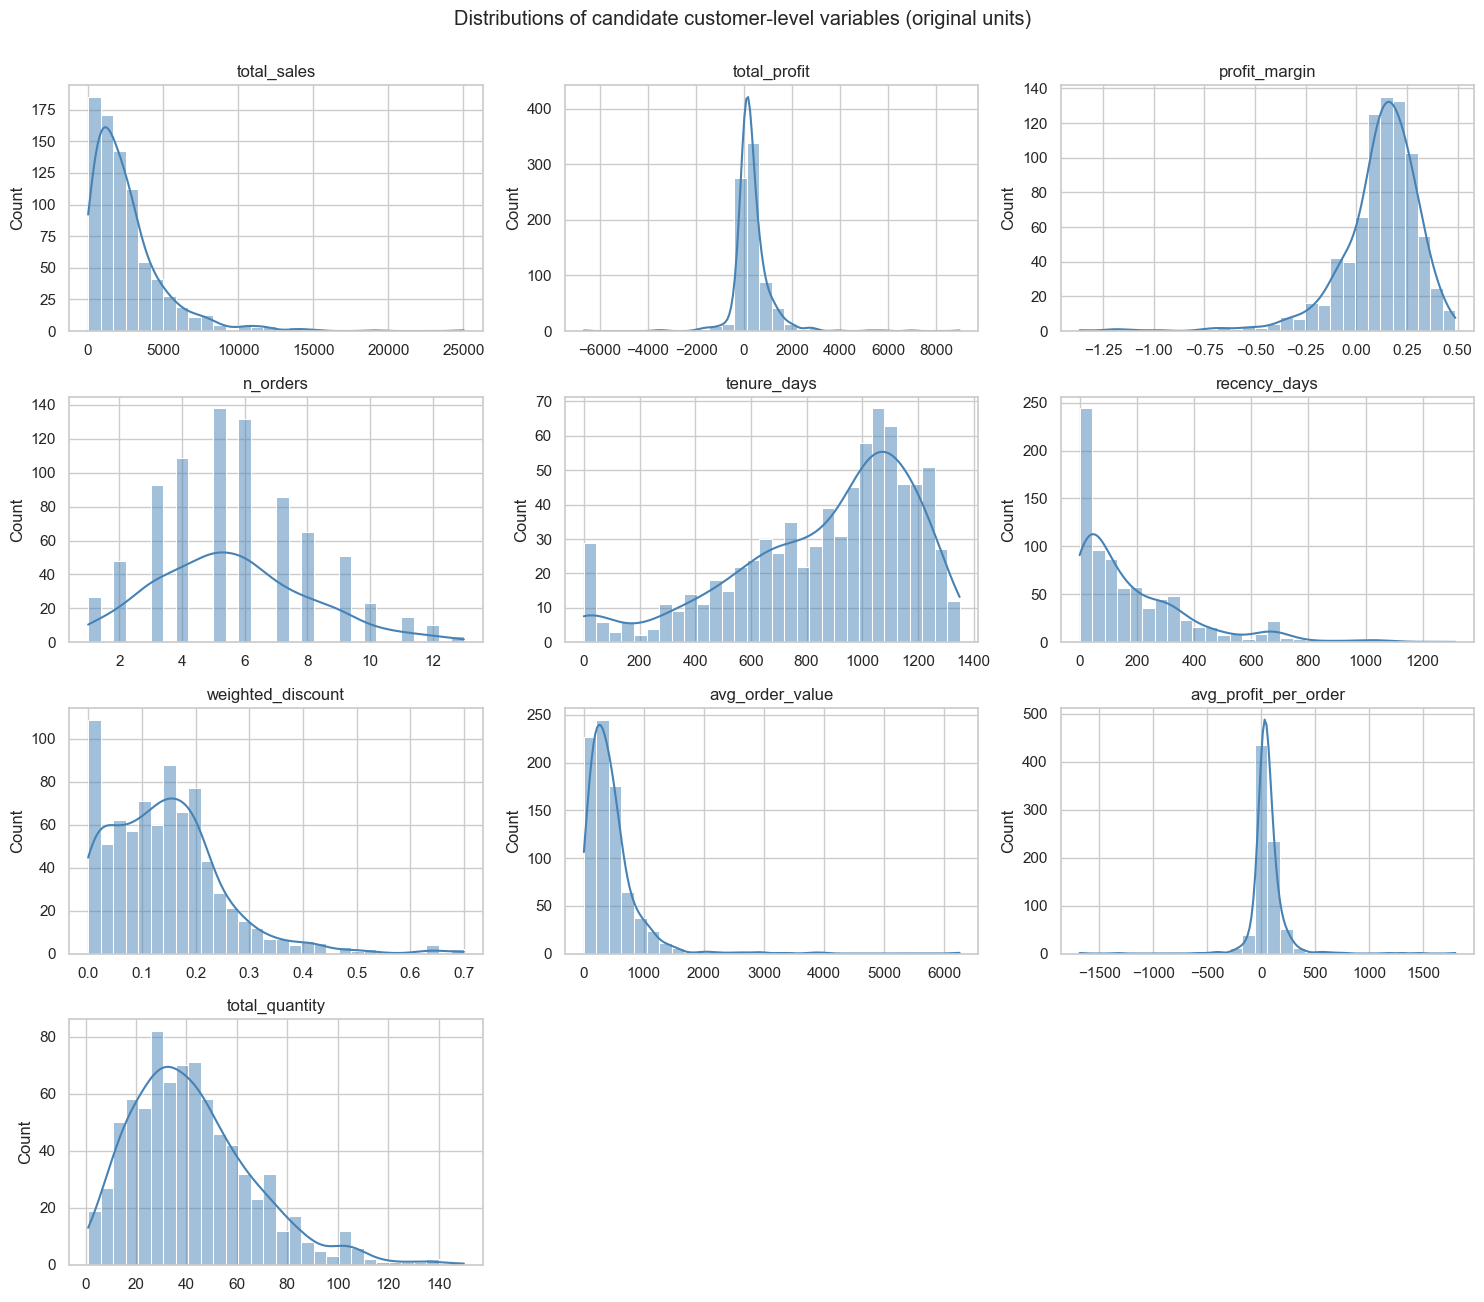

In [19]:
# Q1: what does each distribution look like?
fig, axes = plt.subplots(4, 3, figsize=(15, 13))
axes = axes.flatten()
for i, col in enumerate(candidate_features):
    sns.histplot(customers[col], bins=30, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
for j in range(len(candidate_features), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Distributions of candidate customer-level variables (original units)", y=1.00)
plt.tight_layout()
plt.show()

In [20]:
# Skewness of each candidate (stats.skew: 0 = symmetric, > 0 = long right tail, < 0 = long left tail)
skew_table = pd.DataFrame({"skewness": [stats.skew(customers[c].dropna()) for c in candidate_features]},
                          index=candidate_features).sort_values("skewness", key=abs, ascending=False)
skew_table

,skewness
avg_order_value,4.926
total_sales,2.738
profit_margin,-2.312
total_profit,2.220
recency_days,1.823
weighted_discount,1.338
avg_profit_per_order,1.104
total_quantity,0.949
tenure_days,-0.944
n_orders,0.428


**How to read the output.** Look for (a) long right tails on money variables (a few customers spend or earn far more than typical), (b) variables with a *long left tail* (negative skewness), which behave differently from right-skewed ones, and (c) variables that are only mildly skewed. Do **not** conclude that a skewed variable must be log-transformed: the decision is made in Section 10 using the sign and direction of the skew.

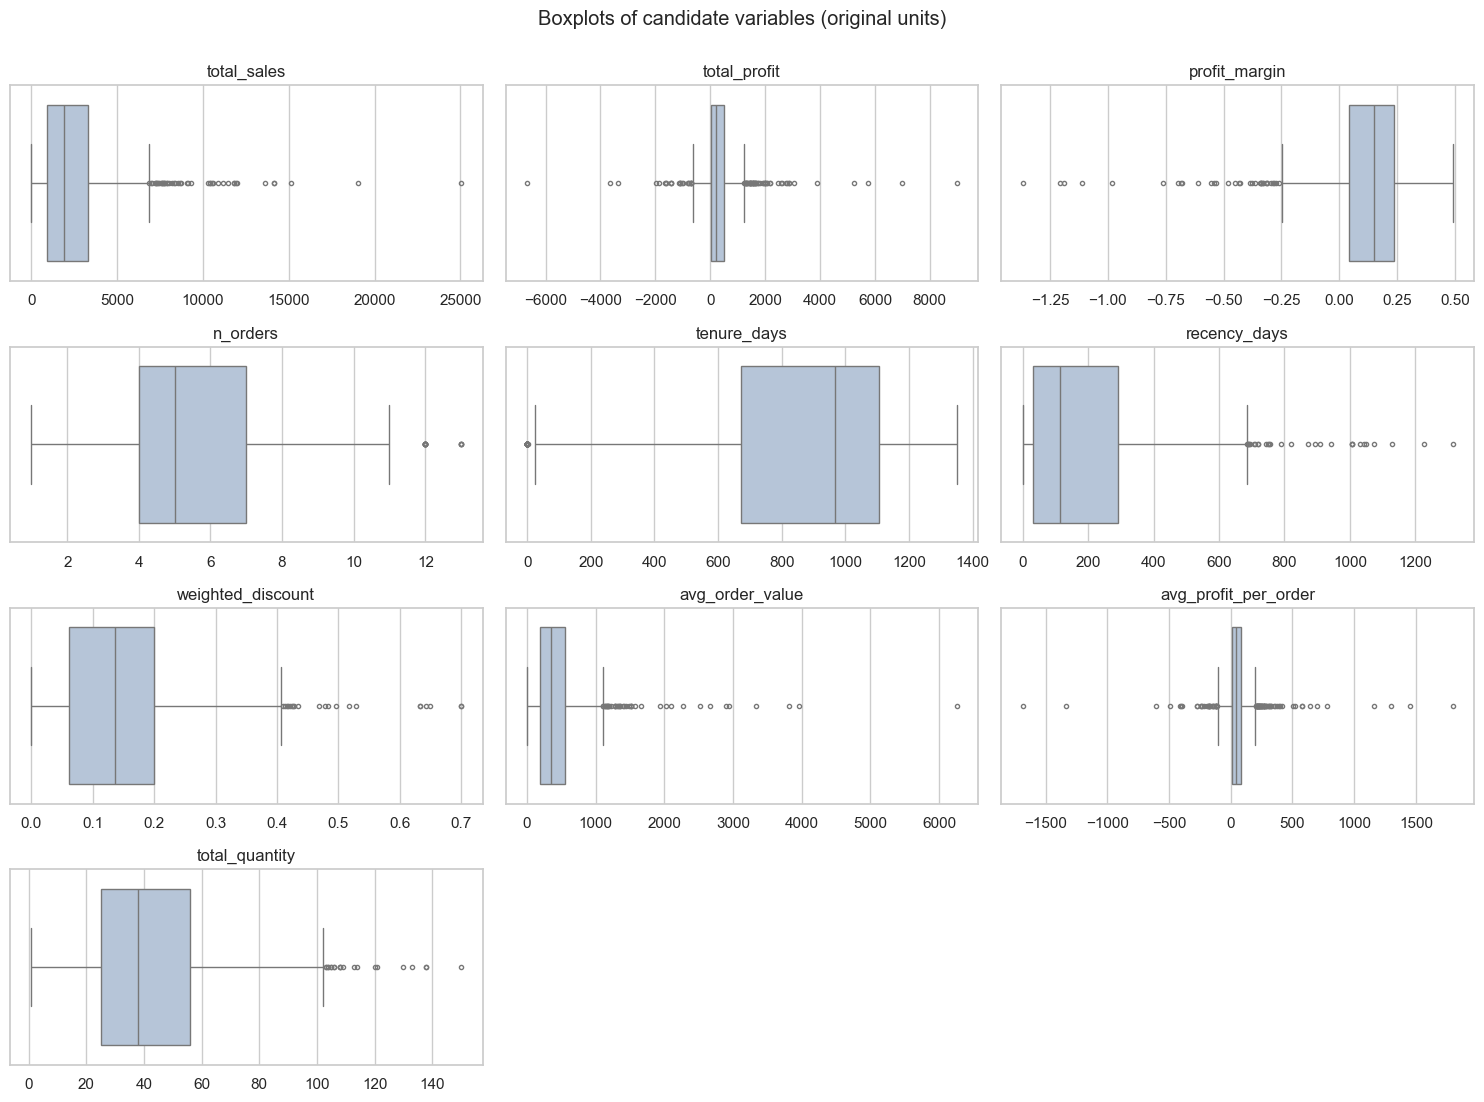

In [21]:
# Q2: where are the extreme values? (boxplots; dots beyond the whiskers are values outside 1.5 x IQR)
fig, axes = plt.subplots(4, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(candidate_features):
    sns.boxplot(x=customers[col], ax=axes[i], color="lightsteelblue", fliersize=3)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
for j in range(len(candidate_features), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Boxplots of candidate variables (original units)", y=1.00)
plt.tight_layout()
plt.show()

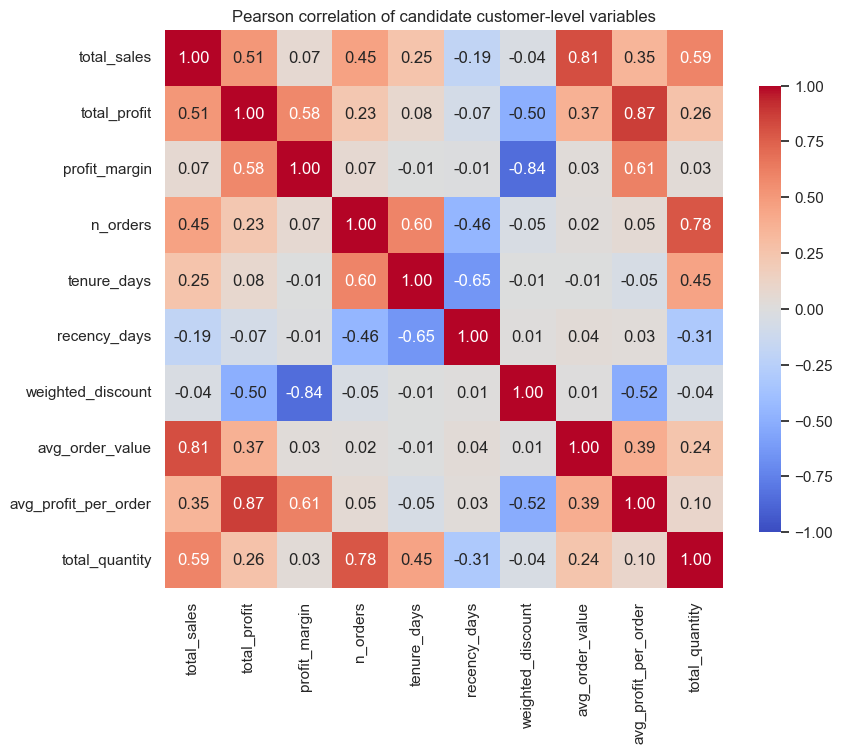

In [22]:
# Q3: which variables move together? (Pearson correlation heatmap)
plt.figure(figsize=(9, 7.5))
corr_pearson = customers[candidate_features].corr()
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Pearson correlation of candidate customer-level variables")
plt.tight_layout()
plt.show()

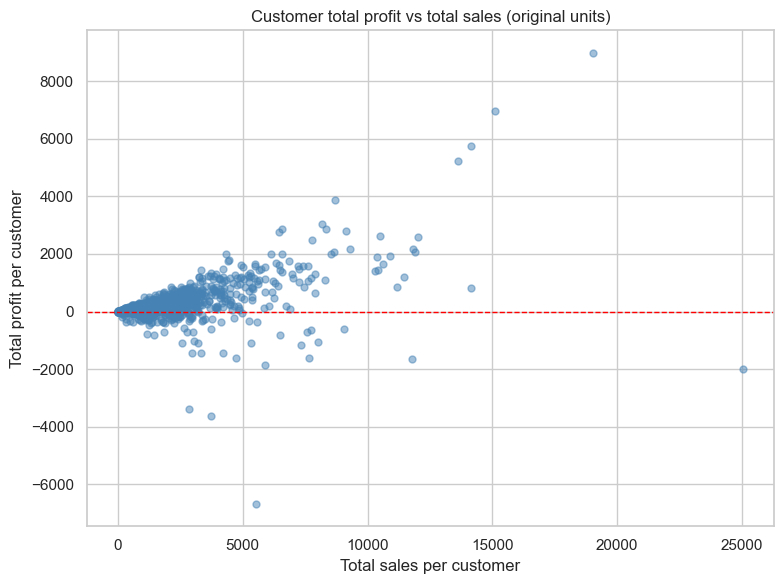

Pearson correlation  : 0.511
Spearman correlation : 0.552


In [23]:
# Q4: is profit just a rescaled version of sales?
plt.figure(figsize=(8, 6))
plt.scatter(customers["total_sales"], customers["total_profit"], alpha=0.5, s=25, color="steelblue")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Total sales per customer")
plt.ylabel("Total profit per customer")
plt.title("Customer total profit vs total sales (original units)")
plt.tight_layout()
plt.show()

print("Pearson correlation  :", round(customers["total_sales"].corr(customers["total_profit"]), 3))
print("Spearman correlation :", round(customers["total_sales"].corr(customers["total_profit"], method="spearman"), 3))

**How to read the output.**
* *Heatmap:* note which pairs have large $|r|$. A large correlation flags a *candidate* for redundancy; it is examined properly in Section 8, not decided here.
* *Scatter:* if customers with similar sales have very different profits (including losses), then profit carries information that sales does not, which supports treating profitability as its own dimension instead of clustering on sales or profit alone.
* Pearson measures *linear* association and is sensitive to extreme values; Spearman uses ranks. If they differ a lot, extreme customers are influencing the linear picture.

---
## 8. Feature Selection

**What / why:** clustering on every available number would over-weight overlapping information (e.g. sales and average order value are partly the same quantity) and make results hard to interpret. We start from the *initial proposed set* agreed earlier:

`total_sales, total_profit, profit_margin, n_orders, tenure_days, recency_days, weighted_discount`

and test it before finalising: **(1)** recalculate correlations, **(2)** check the distributions, **(3)** check for mathematical redundancy, **(4)** ask whether each feature adds a *distinct business dimension*.

**Concept: redundancy vs useful correlation.** Two variables can be strongly correlated because one is (partly) *computed from* the other (**mathematical redundancy**, e.g. `avg_order_value = total_sales / n_orders`) or because two genuinely different behaviors tend to co-occur (**substantive correlation**, e.g. heavier discounting and lower margins). We do not drop variables merely because $|r|$ is high: we ask whether the second variable adds different information for the business question.

In [24]:
# Recalculate the correlations that matter (Pearson AND Spearman) for the pairs under discussion
pairs = [
    ("total_sales", "avg_order_value", "avg_order_value = total_sales / n_orders (partly mechanical)"),
    ("total_profit", "avg_profit_per_order", "avg_profit_per_order = total_profit / n_orders (partly mechanical)"),
    ("n_orders", "total_quantity", "orders vs units bought (both measure volume of activity)"),
    ("profit_margin", "weighted_discount", "margin is profit/sales; discount is one input into profit (substantive link)"),
    ("total_sales", "total_profit", "is profit just scaled sales?"),
    ("total_profit", "profit_margin", "absolute profit vs profit rate"),
    ("total_sales", "n_orders", "value vs frequency"),
    ("n_orders", "tenure_days", "frequency vs how long active"),
    ("tenure_days", "recency_days", "how long active vs how recently active"),
]
rows = []
for a, b, note in pairs:
    rows.append({"variable_1": a, "variable_2": b,
                 "pearson_r": customers[a].corr(customers[b]),
                 "spearman_rho": customers[a].corr(customers[b], method="spearman"),
                 "nature_of_relationship": note})
pair_table = pd.DataFrame(rows)
pair_table

,variable_1,variable_2,pearson_r,spearman_rho,nature_of_relationship
0,total_sales,avg_order_value,0.813,0.869,avg_order_value = total_sales / n_orders (part...
1,total_profit,avg_profit_per_order,0.870,0.956,avg_profit_per_order = total_profit / n_orders...
2,n_orders,total_quantity,0.785,0.786,orders vs units bought (both measure volume of...
3,profit_margin,weighted_discount,-0.844,-0.787,margin is profit/sales; discount is one input ...
4,total_sales,total_profit,0.511,0.552,is profit just scaled sales?
5,total_profit,profit_margin,0.583,0.702,absolute profit vs profit rate
6,total_sales,n_orders,0.455,0.593,value vs frequency
7,n_orders,tenure_days,0.599,0.568,frequency vs how long active
8,tenure_days,recency_days,-0.646,-0.606,how long active vs how recently active


**How to read the output.** For each pair: is the correlation large in *both* Pearson and Spearman (a robust relationship) or only in one (driven by a few extreme customers)? Then apply the reasoning in the table below: *mechanical* pairs (a ratio and one of its own ingredients) are the strongest redundancy candidates; *substantive* pairs (margin and discount) need a business judgement.

In [25]:
# The proposed / final clustering features and the decisions (reasoning is stated; the measured r values are attached automatically)
FINAL_FEATURES = ["total_sales", "total_profit", "profit_margin", "n_orders", "tenure_days", "recency_days", "weighted_discount"]

decisions = [
    ("total_sales", "Customer value", "Include", "Revenue size of the customer; not a rescaled copy of profit (checked above)."),
    ("total_profit", "Profitability (absolute)", "Include", "The economic contribution (or loss) generated; central to the objective."),
    ("profit_margin", "Profitability (rate)", "Include", "Profit relative to sales; separates 'large but unprofitable' from 'large and profitable'. Related to total_profit but not the same information."),
    ("n_orders", "Purchasing activity", "Include", "Standard purchase-frequency measure (RFM-style)."),
    ("tenure_days", "Activity duration", "Include", "How long the customer has been active in the observation window."),
    ("recency_days", "Activity recency", "Include", "How recently the customer bought (relative to the dataset's last date)."),
    ("weighted_discount", "Discount behavior", "Include", "Discount level on the money actually spent; required as its own dimension. Related to profit_margin, but margin also reflects product mix and cost."),
    ("avg_order_value", "Sales", "Exclude", "Mostly total_sales / n_orders; both ingredients are already included."),
    ("avg_profit_per_order", "Profitability", "Exclude", "Mostly total_profit / n_orders; both ingredients are already included."),
    ("total_quantity", "Sales", "Exclude", "Volume overlaps with n_orders and total_sales; adds little distinct information."),
    ("avg_discount", "Discount", "Exclude", "Superseded by the sales-weighted version (see Section 6)."),
    ("avg_profit_per_line", "Profitability", "Exclude", "Derived from total_profit and n_line_items; kept for description only."),
    ("n_line_items", "Activity", "Exclude", "Overlaps with n_orders and total_quantity."),
    ("orders_per_30_days", "Activity", "Exclude", "Function of n_orders and tenure_days; undefined for single-order customers."),
]
feature_table = pd.DataFrame(decisions, columns=["Feature", "Dimension", "Include/Exclude", "Reason"])

# Attach the measured correlation with the closest 'sibling' feature that IS included
sibling = {"avg_order_value": "total_sales", "avg_profit_per_order": "total_profit", "total_quantity": "n_orders",
           "avg_discount": "weighted_discount", "avg_profit_per_line": "total_profit", "n_line_items": "n_orders",
           "profit_margin": "weighted_discount", "weighted_discount": "profit_margin"}
feature_table["compared_with"] = feature_table["Feature"].map(sibling)
feature_table["measured_pearson_r"] = [customers[f].corr(customers[s]) if isinstance(s, str) else np.nan
                                       for f, s in zip(feature_table["Feature"], feature_table["compared_with"])]
pd.set_option("display.max_colwidth", 130)
feature_table

,Feature,Dimension,Include/Exclude,Reason,compared_with,measured_pearson_r
0,total_sales,Customer value,Include,Revenue size of the customer; not a rescaled copy of profit (checked above).,NaN,NaN
1,total_profit,Profitability (absolute),Include,The economic contribution (or loss) generated; central to the objective.,NaN,NaN
2,profit_margin,Profitability (rate),Include,Profit relative to sales; separates 'large but unprofitable' from 'large and profitable'. Related to total_profit but not the ...,weighted_discount,-0.844
3,n_orders,Purchasing activity,Include,Standard purchase-frequency measure (RFM-style).,NaN,NaN
4,tenure_days,Activity duration,Include,How long the customer has been active in the observation window.,NaN,NaN
5,recency_days,Activity recency,Include,How recently the customer bought (relative to the dataset's last date).,NaN,NaN
6,weighted_discount,Discount behavior,Include,"Discount level on the money actually spent; required as its own dimension. Related to profit_margin, but margin also reflects ...",profit_margin,-0.844
7,avg_order_value,Sales,Exclude,Mostly total_sales / n_orders; both ingredients are already included.,total_sales,0.813
8,avg_profit_per_order,Profitability,Exclude,Mostly total_profit / n_orders; both ingredients are already included.,total_profit,0.870
9,total_quantity,Sales,Exclude,Volume overlaps with n_orders and total_sales; adds little distinct information.,n_orders,0.785


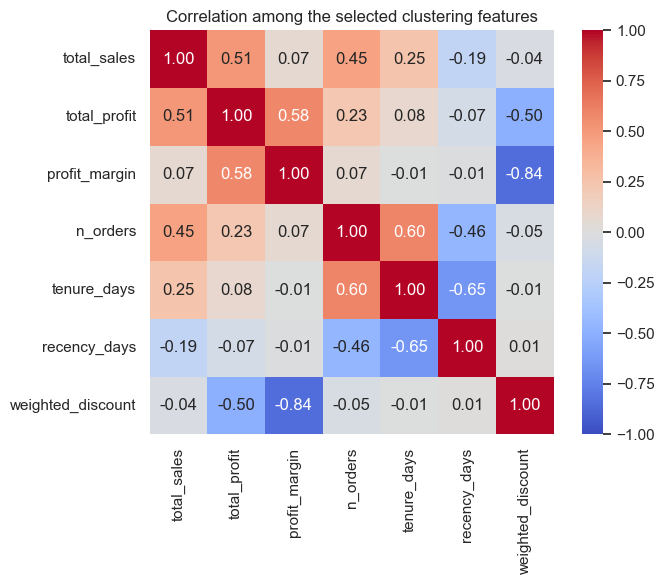

Strongest pairwise correlation among the selected features: ('profit_margin', 'weighted_discount') r = -0.844


In [26]:
# Final check: correlation structure among the SELECTED features only
final_corr = customers[FINAL_FEATURES].corr()

plt.figure(figsize=(7.5, 6))
sns.heatmap(final_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation among the selected clustering features")
plt.tight_layout()
plt.show()

# Strongest pair (ignoring the diagonal)
upper = final_corr.where(np.triu(np.ones(final_corr.shape), k=1).astype(bool)).stack()
strongest = upper.abs().idxmax()
print("Strongest pairwise correlation among the selected features:", strongest, "r =", round(upper[strongest], 3))

**How to read the output.** Ask of *each* selected feature: "does it add a business dimension the others do not?" If the strongest remaining correlation is between `profit_margin` and `weighted_discount`, remember the reasoning above: the project requires a distinct discount dimension, and the two are related but not identical. **Write your own final decision** (keep both / drop one) in the cell below, based on the numbers you just saw; the notebook proceeds with the agreed 7 features unless you change `FINAL_FEATURES`.

*Your decision (edit after reviewing the output):* ______________________________

---
## 9. Outlier Analysis

**What / why:** customer-level money variables are naturally skewed. Before deciding *what to do* about extreme values we must decide *what they are*:

* **Data errors** - impossible or invalid values (negative tenure, margin above 100%, non-positive sales, invalid dates). These would be corrected or removed.
* **Legitimate extreme customers** - genuinely very high sales, very high profit, or very large *losses*. These are real business signals; deleting them would distort the segmentation, so we **keep** them and handle their influence through transformation and robust scaling (Sections 10-11).

**Concept:** an outlier is a *statistical* label (far from the bulk); it says nothing about whether the value is *wrong*. The **IQR rule** flags values outside $[Q_1-1.5\,\text{IQR},\;Q_3+1.5\,\text{IQR}]$.

In [27]:
# --- Percentiles and IQR-based summary for the selected features ---
percentiles = customers[FINAL_FEATURES].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(percentiles)

rows = []
for col in FINAL_FEATURES:
    x = customers[col]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rows.append({"feature": col, "Q1": q1, "Q3": q3, "IQR": iqr, "lower_fence": lower, "upper_fence": upper,
                 "n_below": int((x < lower).sum()), "n_above": int((x > upper).sum()),
                 "pct_flagged": 100 * ((x < lower) | (x > upper)).mean(), "skewness": stats.skew(x)})
iqr_table = pd.DataFrame(rows).set_index("feature")
iqr_table

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
total_sales,801.000,"2,546.105","2,503.547",3.024,16.739,162.232,899.260,"1,912.223","3,278.059","7,252.608","11,809.296","25,035.082"
total_profit,801.000,328.687,808.773,"-6,670.096","-1,441.806",-341.526,31.838,196.874,514.653,"1,449.519","2,798.369","8,981.324"
profit_margin,801.000,0.116,0.205,-1.367,-0.679,-0.222,0.043,0.148,0.237,0.364,0.444,0.489
n_orders,801.000,5.578,2.453,1.000,1.000,2.000,4.000,5.000,7.000,10.000,12.000,13.000
tenure_days,801.000,866.102,326.985,0.000,0.000,145.000,672.000,967.000,"1,104.000","1,256.000","1,318.000","1,350.000"
recency_days,801.000,191.541,212.977,0.000,1.000,6.000,30.000,112.000,292.000,666.000,"1,005.000","1,314.000"
weighted_discount,801.000,0.143,0.108,0.000,0.000,0.001,0.061,0.136,0.200,0.328,0.497,0.700


,Q1,Q3,IQR,lower_fence,upper_fence,n_below,n_above,pct_flagged,skewness
feature,,,,,,,,,
total_sales,899.260,"3,278.059","2,378.799","-2,668.939","6,846.257",0,46,5.743,2.738
total_profit,31.838,514.653,482.815,-692.385,"1,238.875",24,54,9.738,2.220
profit_margin,0.043,0.237,0.195,-0.250,0.530,34,0,4.245,-2.312
n_orders,4.000,7.000,3.000,-0.500,11.500,0,14,1.748,0.428
tenure_days,672.000,"1,104.000",432.000,24.000,"1,752.000",28,0,3.496,-0.944
recency_days,30.000,292.000,262.000,-363.000,685.000,0,29,3.620,1.823
weighted_discount,0.061,0.200,0.139,-0.147,0.408,0,21,2.622,1.338


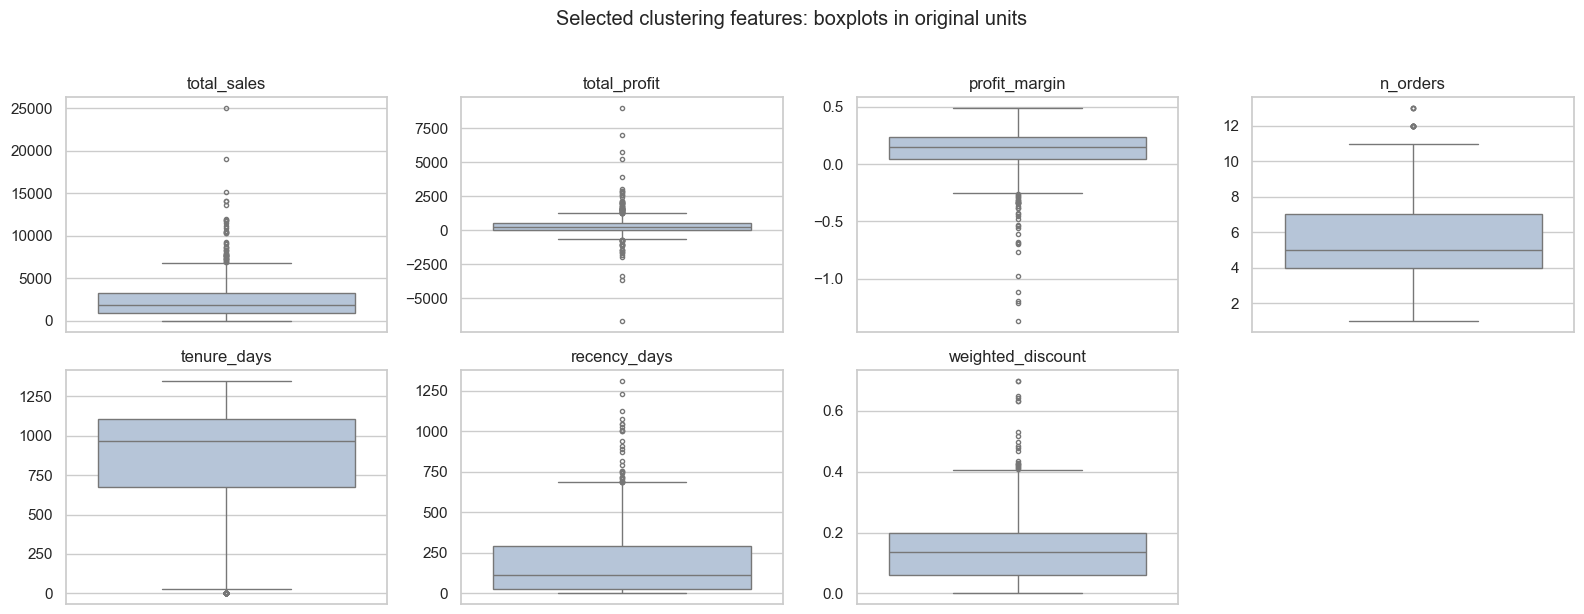

In [28]:
# --- Boxplots of the selected features (original units) ---
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(FINAL_FEATURES):
    sns.boxplot(y=customers[col], ax=axes[i], color="lightsteelblue", fliersize=3)
    axes[i].set_title(col)
    axes[i].set_ylabel("")
fig.delaxes(axes[-1])
fig.suptitle("Selected clustering features: boxplots in original units", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# --- Look at the most extreme customers individually (are their profiles internally consistent?) ---
show_cols = ["Customer ID", "customer_name", "segment"] + FINAL_FEATURES + ["n_line_items"]
print("Top 5 by total_sales:");         display(customers.nlargest(5, "total_sales")[show_cols])
print("Top 5 by total_profit:");        display(customers.nlargest(5, "total_profit")[show_cols])
print("Largest 5 losses (total_profit):"); display(customers.nsmallest(5, "total_profit")[show_cols])
print("Top 5 by weighted_discount:");   display(customers.nlargest(5, "weighted_discount")[show_cols])

Top 5 by total_sales:


,Customer ID,customer_name,segment,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount,n_line_items
708,SM-20320,Sean Miller,Home Office,"25,035.082","-1,983.428",-0.079,4,1209,83,0.479,14
749,TC-20980,Tamara Chand,Corporate,"19,052.218","8,981.324",0.471,5,750,308,0.002,12
629,RB-19360,Raymond Buch,Consumer,"15,117.339","6,976.096",0.461,6,542,5,0.004,18
441,KL-16645,Ken Lonsdale,Consumer,"14,153.229",805.480,0.057,11,1033,130,0.059,28
677,SC-20095,Sanjit Chand,Consumer,"14,142.334","5,757.412",0.407,9,1068,258,0.022,22


Top 5 by total_profit:


,Customer ID,customer_name,segment,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount,n_line_items
749,TC-20980,Tamara Chand,Corporate,"19,052.218","8,981.324",0.471,5,750,308,0.002,12
629,RB-19360,Raymond Buch,Consumer,"15,117.339","6,976.096",0.461,6,542,5,0.004,18
677,SC-20095,Sanjit Chand,Consumer,"14,142.334","5,757.412",0.407,9,1068,258,0.022,22
6,AB-10105,Adrian Barton,Consumer,"13,629.731","5,220.356",0.383,9,1004,11,0.054,18
160,CM-12385,Christopher Martinez,Consumer,"8,713.652","3,883.076",0.446,3,658,270,0.046,7


Largest 5 losses (total_profit):


,Customer ID,customer_name,segment,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount,n_line_items
180,CS-12505,Cindy Stewart,Consumer,"5,521.955","-6,670.096",-1.208,5,975,309,0.632,8
466,LF-17185,Luke Foster,Consumer,"3,711.699","-3,636.942",-0.980,6,936,226,0.517,13
719,SR-20425,Sharelle Roach,Home Office,"2,826.249","-3,366.861",-1.191,2,1038,166,0.644,6
708,SM-20320,Sean Miller,Home Office,"25,035.082","-1,983.428",-0.079,4,1209,83,0.479,14
165,CP-12340,Christine Phan,Corporate,"5,888.275","-1,850.303",-0.314,8,1224,69,0.390,15


Top 5 by weighted_discount:


,Customer ID,customer_name,segment,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount,n_line_items
416,JT-12540,Jill Trafton,Consumer,144.588,-197.604,-1.367,2,365,195,0.700,2
768,TS-21085,Thais Sissman,Consumer,4.833,-3.316,-0.686,2,537,266,0.700,2
140,CD-11980,Carol Darley,Consumer,320.806,-356.628,-1.112,2,114,196,0.650,5
719,SR-20425,Sharelle Roach,Home Office,"2,826.249","-3,366.861",-1.191,2,1038,166,0.644,6
180,CS-12505,Cindy Stewart,Consumer,"5,521.955","-6,670.096",-1.208,5,975,309,0.632,8


In [30]:
# --- Explicit test for DATA ERRORS (impossible values), not merely "far from the mean" ---
error_checks = {
    "total_sales <= 0": int((customers["total_sales"] <= 0).sum()),
    "profit_margin > 1 (profit larger than sales)": int((customers["profit_margin"] > 1).sum()),
    "tenure_days < 0": int((customers["tenure_days"] < 0).sum()),
    "recency_days < 0": int((customers["recency_days"] < 0).sum()),
    "n_orders < 1": int((customers["n_orders"] < 1).sum()),
    "weighted_discount outside [0, 1]": int((~customers["weighted_discount"].between(0, 1)).sum()),
    "missing values in selected features": int(customers[FINAL_FEATURES].isna().sum().sum()),
}
display(pd.Series(error_checks, name="customers affected").to_frame())

n_neg = int((customers["total_profit"] < 0).sum())
print(f"Customers with negative total profit: {n_neg} ({n_neg / len(customers):.1%}): KEPT (economically meaningful).")
n_any = int(((customers[FINAL_FEATURES] < iqr_table["lower_fence"]) | (customers[FINAL_FEATURES] > iqr_table["upper_fence"])).any(axis=1).sum())
print(f"Customers outside the IQR fences on at least one selected feature: {n_any} ({n_any / len(customers):.1%}): KEPT (legitimate extremes unless shown otherwise).")

,customers affected
total_sales <= 0,0
profit_margin > 1 (profit larger than sales),0
tenure_days < 0,0
recency_days < 0,0
n_orders < 1,0
"weighted_discount outside [0, 1]",0
missing values in selected features,0


Customers with negative total profit: 154 (19.2%): KEPT (economically meaningful).
Customers outside the IQR fences on at least one selected feature: 165 (20.6%): KEPT (legitimate extremes unless shown otherwise).


**How to read the output.**
* If every line in the *data-error* table is `0`, there is **no evidence of invalid customer records**: the extremes are legitimate customers, and we keep all of them.
* For the individual extreme customers, check that the *combination* of values makes business sense (e.g. very high sales together with a large loss is a real and important pattern, not an error).
* If any error count is non-zero, inspect those customers and document what you decide before continuing.
* The IQR rule flags a *share* of customers on skewed variables partly because of the skew itself; that is a reason to transform and robust-scale, not to delete.

---
## 10. Feature Transformation

**What / why:** Euclidean distance (used by both K-Means and Ward) is easily dominated by a few very large values. A transformation that pulls in a long tail can prevent a handful of customers from stretching the geometry of the whole data set. But we transform **only where the data justify it**.

**Rules applied (decided by the data, not by habit)**

| Situation | Transformation | Reason |
|---|---|---|
| Right-skewed (skewness $>1$), all values $\ge 0$ | `log1p(x)` = $\ln(1+x)$ | Compresses a long right tail; defined at 0 |
| Right-skewed (skewness $>1$), can be **negative** | signed log: $\operatorname{sign}(x)\cdot\ln(1+|x|)$ | Compresses large magnitudes on *both* sides of zero and keeps the sign; a plain log is undefined for negative values (losses) |
| Left-skewed, or only mildly skewed | **none** | A log transform compresses the *right* tail, so it cannot fix a left tail; mild skew does not justify altering the variable |

`profit_margin` is a bounded ratio: its typical values are small in magnitude, where $\ln(1+|x|)\approx |x|$, so a log-type transform would barely change it. The rule above leaves it alone unless the data show strong right skew.

**Concept:** transformation changes the *shape* of a distribution; **scaling** (next section) changes its *units*. They are different steps.

We keep an explicit table mapping every **original feature** to its **transformed feature**.

In [31]:
SKEW_THRESHOLD = 1.0      # convention: |skewness| > 1 is "notably skewed"

def signed_log1p(x):
    # sign(x) * log(1 + |x|): works for negative values as well
    return np.sign(x) * np.log1p(np.abs(x))

# --- Decide the transformation for each selected feature from ITS OWN skewness and sign ---
transform_rules = {}
map_rows = []
for col in FINAL_FEATURES:
    skew_before = stats.skew(customers[col])
    has_negative = (customers[col] < 0).any()
    if skew_before > SKEW_THRESHOLD and has_negative:
        rule, why = "signed_log1p", "right-skewed and takes negative values"
    elif skew_before > SKEW_THRESHOLD:
        rule, why = "log1p", "right-skewed and non-negative"
    elif skew_before < -SKEW_THRESHOLD:
        rule, why = "none", "left-skewed: a log would not correct a left tail"
    else:
        rule, why = "none", "skewness not large enough to justify a transformation"
    transform_rules[col] = rule
    map_rows.append({"original_feature": col, "transformation": rule, "skew_before": skew_before, "reason": why})


def apply_transformations(cust):
    # Applies the rules above (decided once, on the primary data) to any customer table
    out = pd.DataFrame(index=cust.index)
    for col in FINAL_FEATURES:
        rule = transform_rules[col]
        if rule == "log1p":
            out[col] = np.log1p(cust[col])
        elif rule == "signed_log1p":
            out[col] = signed_log1p(cust[col])
        else:
            out[col] = cust[col]
    return out


# X_transformed has the SAME column names as the originals, but the values are transformed (see the mapping table)
X_transformed = apply_transformations(customers)

transform_map = pd.DataFrame(map_rows)
transform_map["skew_after"] = [stats.skew(X_transformed[c]) for c in transform_map["original_feature"]]
transform_map

,original_feature,transformation,skew_before,reason,skew_after
0,total_sales,log1p,2.738,right-skewed and non-negative,-1.436
1,total_profit,signed_log1p,2.220,right-skewed and takes negative values,-1.380
2,profit_margin,none,-2.312,left-skewed: a log would not correct a left tail,-2.312
3,n_orders,none,0.428,skewness not large enough to justify a transformation,0.428
4,tenure_days,none,-0.944,skewness not large enough to justify a transformation,-0.944
5,recency_days,log1p,1.823,right-skewed and non-negative,-0.625
6,weighted_discount,log1p,1.338,right-skewed and non-negative,0.903


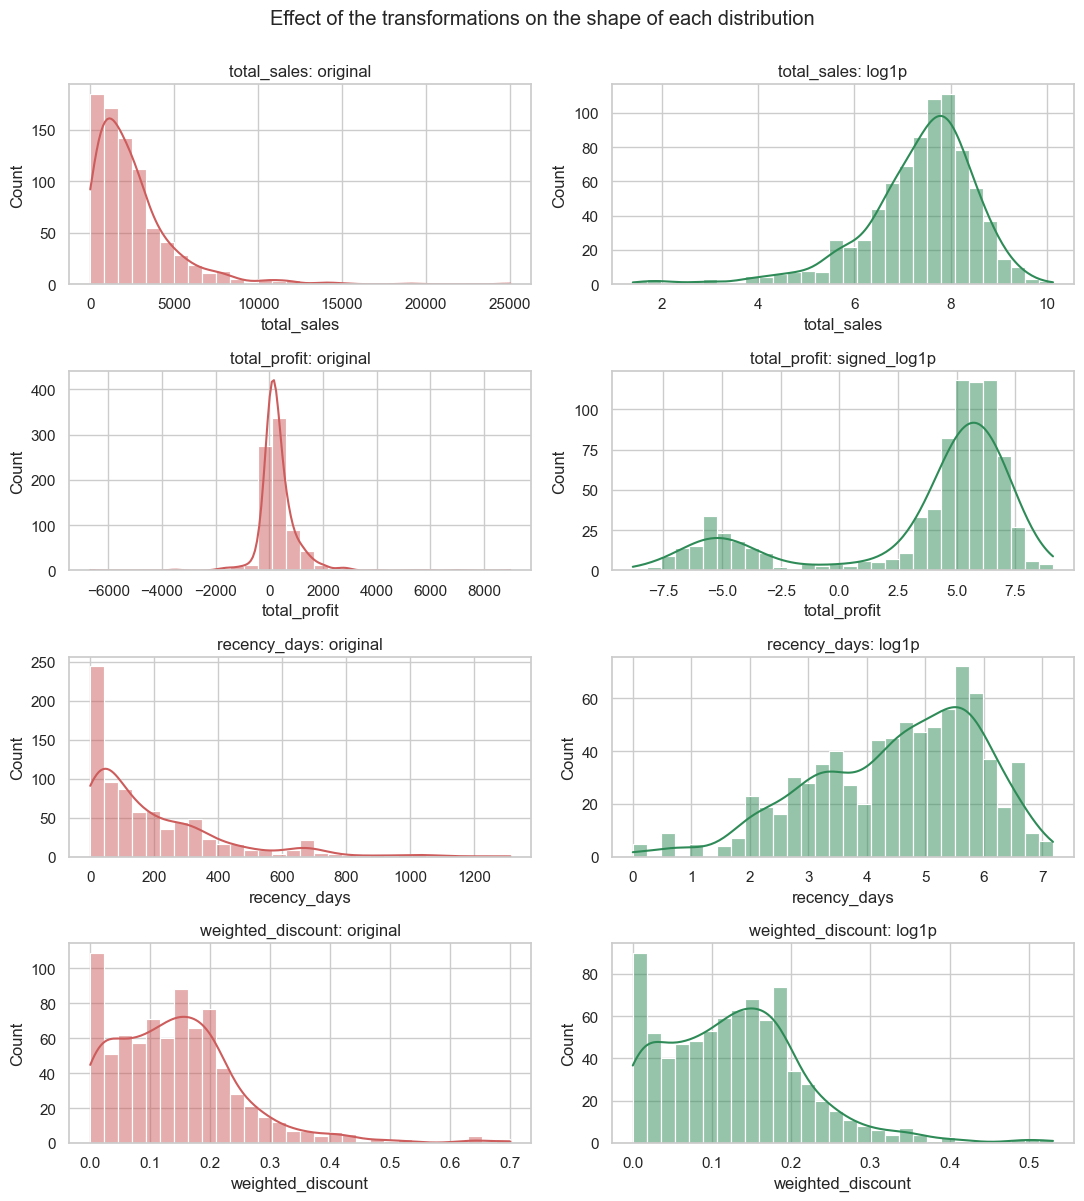

In [32]:
# Before / after for the features that WERE transformed
changed = [c for c, r in transform_rules.items() if r != "none"]
if len(changed) == 0:
    print("No feature exceeded the skewness threshold: no transformation applied.")
else:
    fig, axes = plt.subplots(len(changed), 2, figsize=(11, 3.0 * len(changed)), squeeze=False)
    for i, col in enumerate(changed):
        sns.histplot(customers[col], bins=30, kde=True, ax=axes[i, 0], color="indianred")
        axes[i, 0].set_title(f"{col}: original")
        sns.histplot(X_transformed[col], bins=30, kde=True, ax=axes[i, 1], color="seagreen")
        axes[i, 1].set_title(f"{col}: {transform_rules[col]}")
    fig.suptitle("Effect of the transformations on the shape of each distribution", y=1.00)
    plt.tight_layout()
    plt.show()

**How to read the output.** In the mapping table compare `skew_before` with `skew_after`: transformed features should move closer to 0. Features with `transformation = none` were left alone *deliberately*; read the `reason` column. In the plots check that the right-hand histograms look less one-sided than the left-hand ones. A transformation does **not** remove the extreme customers; it only reduces how much they stretch the distance geometry.

---
## 11. Feature Scaling

**What / why:** the selected features are on wildly different scales (sales in the thousands of dollars, margin between about -1 and 1, discount between 0 and 1). Euclidean distance adds squared differences across features, so a feature with large numbers would dominate purely because of its *units*. Scaling puts all features on a comparable footing.

**Choice: `RobustScaler` (primary).** It centres by the **median** and divides by the **interquartile range**: $x' = (x - \text{median})/\text{IQR}$. Because our data contain legitimate extreme customers, the mean and standard deviation (used by `StandardScaler`) would themselves be pulled by those extremes; the median and IQR are not.

**`StandardScaler` (sensitivity check).** $z=(x-\bar x)/s$. We also build this version so that Section 24 can test whether conclusions depend on the scaler.

**Important:** scaled values are **unit-free numbers**. A scaled `total_sales` of 2 does *not* mean \$2. We therefore never interpret scaled values as currency; business interpretation always uses the original variables.

**The clustering feature matrix `X_cluster`** contains **only** the finalised features after transformation and scaling. `Customer ID` is kept in a separate variable, and geography, `Segment`, names, order/product identifiers and PCA components are **not** included.

In [33]:
# --- Primary scaling: RobustScaler on the transformed features ---
robust_scaler = RobustScaler()
X_cluster = pd.DataFrame(robust_scaler.fit_transform(X_transformed), columns=FINAL_FEATURES, index=customers.index)

# --- Sensitivity version: StandardScaler on the same transformed features ---
standard_scaler = StandardScaler()
X_cluster_std = pd.DataFrame(standard_scaler.fit_transform(X_transformed), columns=FINAL_FEATURES, index=customers.index)

# Customer IDs are stored SEPARATELY (never used as a feature)
customer_ids = customers["Customer ID"]

print("X_cluster shape:", X_cluster.shape, "| columns:", list(X_cluster.columns))
print("Customer IDs kept separately:", len(customer_ids))
assert X_cluster.isna().sum().sum() == 0, "X_cluster contains missing values: investigate before clustering"

X_cluster.describe().T

X_cluster shape: (801, 7) | columns: ['total_sales', 'total_profit', 'profit_margin', 'n_orders', 'tenure_days', 'recency_days', 'weighted_discount']
Customer IDs kept separately: 801


,count,mean,std,min,25%,50%,75%,max
total_sales,801.000,-0.168,0.939,-4.769,-0.583,0.000,0.417,1.989
total_profit,801.000,-0.652,1.580,-5.118,-0.652,0.000,0.348,1.385
profit_margin,801.000,-0.165,1.055,-7.775,-0.540,0.000,0.460,1.750
n_orders,801.000,0.193,0.818,-1.333,-0.333,0.000,0.667,2.667
tenure_days,801.000,-0.234,0.757,-2.238,-0.683,0.000,0.317,0.887
recency_days,801.000,-0.094,0.636,-2.105,-0.576,0.000,0.424,1.093
weighted_discount,801.000,0.012,0.734,-1.040,-0.556,0.000,0.444,3.279


**How to read the output.** After `RobustScaler` each column's **median should be about 0** and its interquartile range about 1. This does *not* bound values to [-1, 1]: extreme customers can still have large scaled values, which is intended (they remain visible). The `assert` line stops the notebook if any missing value would reach the clustering algorithms.

---
## 12. Suitability of Clustering Methods

**What / why:** before running either algorithm we check whether the data look reasonable for *distance-based* clustering, and where each method might struggle.

**Questions and how we address them**

| Question | Evidence in this notebook |
|---|---|
| Is clustering appropriate at all? | There is no target column; we want to discover groups (unsupervised). |
| Is scaling necessary? | Yes: features have very different units (Section 11). |
| Is transformation necessary? | Only for strongly right-skewed features (Section 10). |
| Could outliers affect the methods? | K-Means centroids are means, so extreme points pull centroids; Ward's variance criterion is also sensitive to extremes. We reduce this with transformation and robust scaling, but do not delete customers. |
| Do the feature distributions support spherical clusters? | Inspect the histograms and pairwise plots below. Several humps or elongated, curved shapes would weaken K-Means' assumption. |

**Concept:** K-Means and Ward both work with Euclidean distance and within-cluster variance, so they favour compact, roughly ball-shaped clusters of comparable spread. Real customer data rarely satisfies this exactly, which is why we treat the assumption as something to *check and discuss*, not assume.

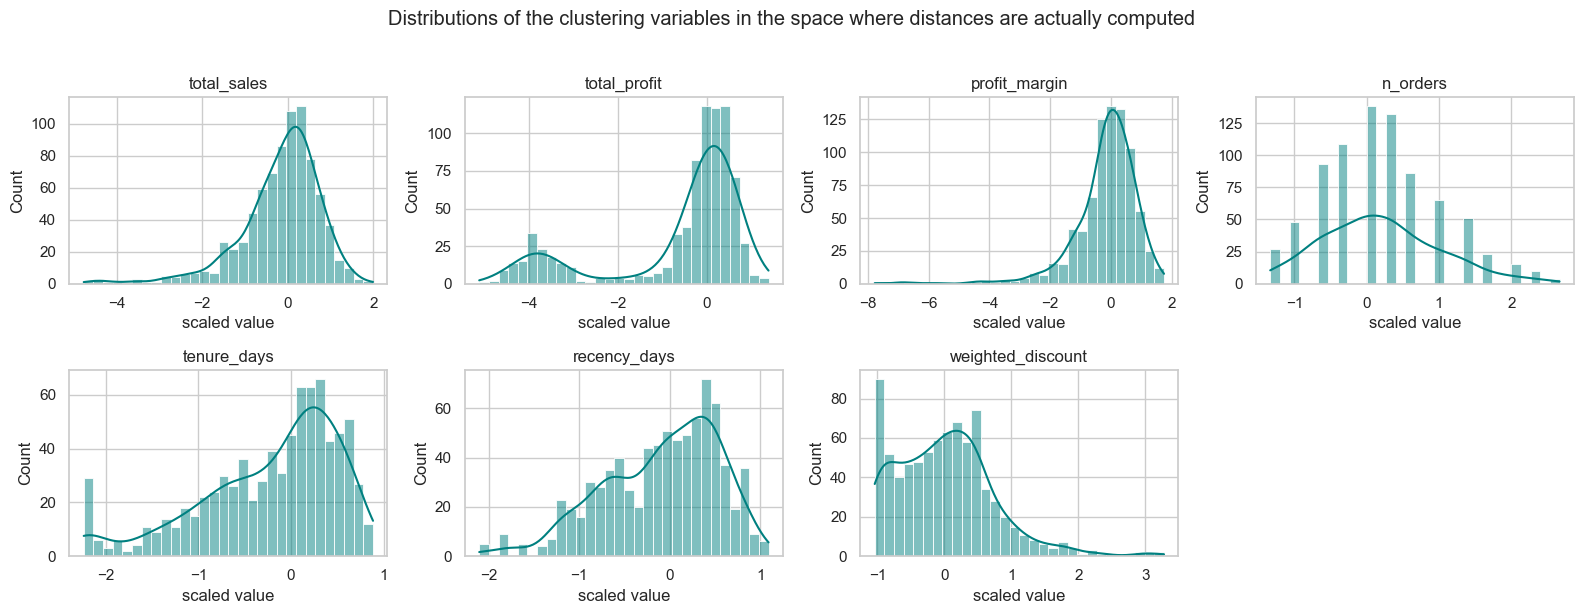

,skewness,min,max,share_with_|value|>3
total_sales,-1.436,-4.769,1.989,0.014
total_profit,-1.380,-5.118,1.385,0.174
profit_margin,-2.312,-7.775,1.750,0.019
n_orders,0.428,-1.333,2.667,0.000
tenure_days,-0.944,-2.238,0.887,0.000
recency_days,-0.625,-2.105,1.093,0.000
weighted_discount,0.903,-1.040,3.279,0.005


Customers with at least one scaled feature beyond +/-3: 151 (18.9%)


In [34]:
# Shape of the FINAL clustering variables (after transformation + robust scaling)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(FINAL_FEATURES):
    sns.histplot(X_cluster[col], bins=30, kde=True, ax=axes[i], color="teal")
    axes[i].set_title(col)
    axes[i].set_xlabel("scaled value")
fig.delaxes(axes[-1])
fig.suptitle("Distributions of the clustering variables in the space where distances are actually computed", y=1.02)
plt.tight_layout()
plt.show()

summary_final_space = pd.DataFrame({
    "skewness": [stats.skew(X_cluster[c]) for c in FINAL_FEATURES],
    "min": X_cluster.min().values,
    "max": X_cluster.max().values,
    "share_with_|value|>3": [(X_cluster[c].abs() > 3).mean() for c in FINAL_FEATURES],
}, index=FINAL_FEATURES)
display(summary_final_space)

any_extreme = (X_cluster.abs() > 3).any(axis=1)
print(f"Customers with at least one scaled feature beyond +/-3: {int(any_extreme.sum())} ({any_extreme.mean():.1%})")

**How to read the output.**
* *Histograms:* look for multiple humps (suggesting genuine groups) versus one broad hump, and for strong remaining one-sidedness.
* *Skewness column:* values near 0 mean the transformation/scaling produced roughly symmetric inputs. Remaining skewness is a caution for both methods.
* *Share beyond +/-3:* customers with many large scaled values will pull centroids and influence Ward merges. A small share means outliers are unlikely to dominate, but they are not zero-impact.
* Write down your own view: *do the distributions support treating K-Means/Ward as reasonable tools here, with caveats?* The analysis continues either way, and later sections (stability, comparison) test how much the answer depends on these assumptions.

---
## 13. K-Means Methodology

**Objective.** Choose $K$ centroids $\mu_1,\dots,\mu_K$ and assign each customer to a cluster $C_k$ so as to minimise the **inertia** (within-cluster sum of squares):

$$\text{Inertia}=\sum_{k=1}^{K}\sum_{x\in C_k}\lVert x-\mu_k\rVert^2 .$$

**Algorithm (Lloyd's).** (1) start from $K$ initial centroids; (2) assign every point to its nearest centroid using Euclidean distance; (3) recompute each centroid as the mean of its members; (4) repeat (2)-(3) until assignments stop changing. Because the result depends on the starting centroids, we use `n_init=10` (ten different starts, best inertia kept) and a fixed `random_state` for reproducibility.

**Assumptions / sensitivities**

* clusters are roughly **spherical** and of **similar spread** (distance to one centroid can only describe ball-shaped groups);
* variables are on **comparable scales** (hence Section 11);
* **outliers** pull centroids (means are not robust);
* $K$ must be supplied in advance.

**Euclidean distance in this problem.** Two customers are "close" if they are similar *simultaneously* in sales, profit, margin, order count, tenure, recency and discount, all in scaled units. The cell below computes one such distance by hand so the formula is concrete.

In [35]:
# A hand-made Euclidean distance between the first two customers in the CLUSTERING space
customer_a = X_cluster.iloc[0]
customer_b = X_cluster.iloc[1]

squared_differences = (customer_a - customer_b) ** 2
print("Squared difference per feature:")
display(squared_differences.to_frame("(a - b)^2"))

distance_by_hand = np.sqrt(squared_differences.sum())
distance_numpy = np.linalg.norm(customer_a.values - customer_b.values)
print("Euclidean distance (formula):", round(distance_by_hand, 4))
print("Euclidean distance (numpy)  :", round(distance_numpy, 4))

Squared difference per feature:


,(a - b)^2
total_sales,1.968
total_profit,17.019
profit_margin,2.775
n_orders,1.000
tenure_days,0.013
recency_days,0.369
weighted_discount,1.181


Euclidean distance (formula): 4.932
Euclidean distance (numpy)  : 4.932


**How to read the output.** The two distances must match. Look at the table of squared differences: the feature with the largest entry contributes most to how "far apart" these two customers are. If one feature dominated *every* pair of customers, that would indicate a scaling problem. This is why scaling is needed for distance-based clustering.

---
## 14. Hierarchical Clustering Methodology

**Agglomerative approach ("bottom-up").** Begin with each customer as its own cluster ($n$ clusters). At each step merge the two *closest* clusters. After $n-1$ merges a single cluster remains. The complete merge history is the **dendrogram**; choosing $K$ means cutting the tree so that $K$ clusters remain.

**Linkage** defines the distance between *clusters*:

| Linkage | Distance between clusters | Tendency |
|---|---|---|
| single | closest pair of points | chains, can produce long "stringy" clusters |
| complete | farthest pair of points | compact clusters, sensitive to extremes |
| average | mean of all pairwise distances | in between |
| **Ward** | the merge that increases total within-cluster sum of squares the least | compact, similar-sized clusters |

**Why Ward is our primary linkage.** Our data are numerical, scaled and compared with Euclidean distance. Ward is designed for exactly this setting and uses the *same objective* as K-Means (within-cluster variance). Average and complete linkage are tried only as sensitivity checks in Section 24.

**Important honesty note.** Because K-Means and Ward both minimise within-cluster variance under Euclidean distance, they are **useful alternative partitioning procedures but not completely independent philosophies**. Agreement between them is therefore *less* surprising than agreement between, say, K-Means and a density-based method; disagreement tells us the data do not have a single, clean, ball-shaped structure.

**Dendrogram.** Vertical height = the cost of a merge. We draw it for visualization only. **The dendrogram is not used to choose K**: the project restricts K-selection to the elbow method and the silhouette score.

The cell below shows the merge history for only six customers, so you can see exactly what the tree stores.

In [36]:
# Tiny worked example: Ward linkage on the first 6 customers
Z_demo = linkage(X_cluster.iloc[:6].values, method="ward")
demo = pd.DataFrame(Z_demo, columns=["cluster_A", "cluster_B", "merge_distance", "size_after_merge"])
demo.index = [f"merge {i + 1}" for i in range(len(demo))]
demo[["cluster_A", "cluster_B", "size_after_merge"]] = demo[["cluster_A", "cluster_B", "size_after_merge"]].astype(int)
print("Customers are numbered 0-5; every new cluster gets the next number (6, 7, ...).")
demo

Customers are numbered 0-5; every new cluster gets the next number (6, 7, ...).


,cluster_A,cluster_B,merge_distance,size_after_merge
merge 1,2,4,0.990,2
merge 2,3,5,1.804,2
merge 3,1,6,2.225,3
merge 4,7,8,2.781,5
merge 5,0,9,6.175,6


**How to read the output.** Each row is one merge: clusters `cluster_A` and `cluster_B` are joined at `merge_distance`, forming a cluster of `size_after_merge` customers, which receives the next unused number. Merge distances never decrease as the tree is built. Reading a full dendrogram works the same way, just with more rows.

---
## 15. Choosing the Number of Clusters (K)

**Rule of this project:** $K$ is chosen using **only two tools**: the **elbow method (inertia, K-Means only)** and the **silhouette score (both methods)**. No other index is used to select $K$ (no Calinski-Harabasz, Davies-Bouldin, gap statistic, dendrogram merge gaps, or ARI). $K$ is examined for $K=2,\dots,8$, always in the same feature space `X_cluster`.

### 15.1 Elbow method (K-Means only)

**Inertia** is the within-cluster sum of squares (Section 13): total squared distance from each customer to its own centroid. It measures *within-cluster variation*: smaller = tighter clusters.

* Inertia **always decreases** as $K$ grows: more centroids can only bring points closer to a centroid (with $K=n$ every point is its own cluster and inertia is 0). So the *lowest inertia is never automatically the right K*.
* We look for the **elbow**: the $K$ after which extra clusters bring only *diminishing improvement*. If the curve bends gradually, with no obvious elbow, we say so honestly instead of forcing one.
* Inertia is a K-Means quantity (it is defined through centroids). **It is not computed for hierarchical clustering.**

C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

,K,inertia,reduction_vs_previous_K,pct_reduction_vs_previous_K
0,2,"2,887.376",NaN,NaN
1,3,"2,199.101",688.275,23.837
2,4,"1,946.591",252.510,11.482
3,5,"1,733.806",212.785,10.931
4,6,"1,591.785",142.021,8.191
5,7,"1,491.382",100.403,6.308
6,8,"1,385.995",105.387,7.066


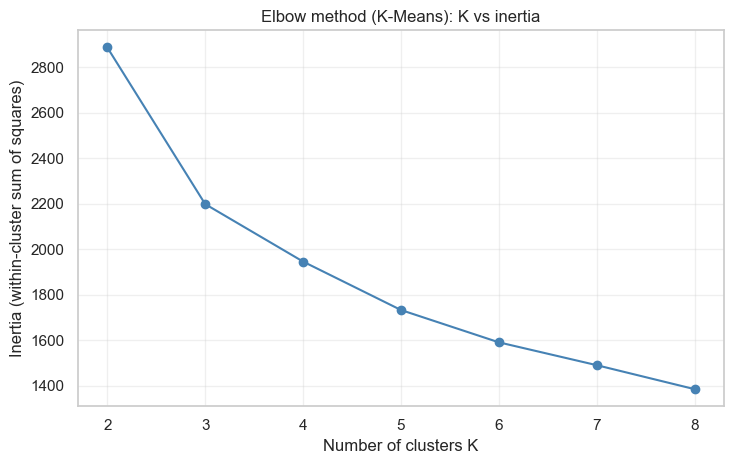

In [37]:
# Inertia of K-Means for K = 2..8 (same feature space, same seed, n_init = 10)
inertias = []
for k in K_RANGE:
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    model.fit(X_cluster)
    inertias.append(model.inertia_)

elbow_table = pd.DataFrame({"K": K_RANGE, "inertia": inertias})
elbow_table["reduction_vs_previous_K"] = -elbow_table["inertia"].diff()
elbow_table["pct_reduction_vs_previous_K"] = 100 * elbow_table["reduction_vs_previous_K"] / elbow_table["inertia"].shift(1)
display(elbow_table)

plt.figure(figsize=(7.5, 4.8))
plt.plot(elbow_table["K"], elbow_table["inertia"], marker="o", color="steelblue")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow method (K-Means): K vs inertia")
plt.xticks(K_RANGE)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**How to read the output.** Describe the *shape* of your own curve in words. Look at the `pct_reduction_vs_previous_K` column: is there a K after which the percentage reduction drops noticeably and then stays small (an elbow)? Or does inertia fall smoothly with no clear bend (then there is no obvious elbow, and you should say so)? Do not pick a K just because it is low or high: only the *pattern of diminishing returns* is informative.

*Your observation (write after running):* ______________________________

### 15.2 Silhouette score (K-Means and Hierarchical)

For each customer $i$:

* $a(i)$ = mean distance to the *other members of its own cluster* (**cohesion**; smaller is better)
* $b(i)$ = mean distance to the members of the *nearest other cluster* (**separation**; larger is better)
* $s(i)=\dfrac{b(i)-a(i)}{\max\{a(i),\,b(i)\}}\in[-1,1]$

The **average silhouette** is the mean of $s(i)$ over customers. A value near +1 means customers sit well inside their clusters and far from others; near 0 means clusters touch/overlap; negative means many customers may sit in the wrong cluster. Higher generally means more cohesive and better-separated clusters.

**Limitations.** (1) It is built from Euclidean distances, so it favours compact, roughly spherical clusters, just like K-Means and Ward; (2) it often prefers very small $K$ (two big blobs) even when a finer split is more useful for the business; (3) it summarises geometry, not business meaning; (4) values are not comparable across different feature spaces. It is therefore *one* piece of evidence, together with the elbow, cluster sizes and interpretability.

C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

,K,kmeans_silhouette,hierarchical_silhouette
0,2,0.516,0.518
1,3,0.317,0.247
2,4,0.255,0.234
3,5,0.251,0.221
4,6,0.239,0.203
5,7,0.212,0.171
6,8,0.182,0.142


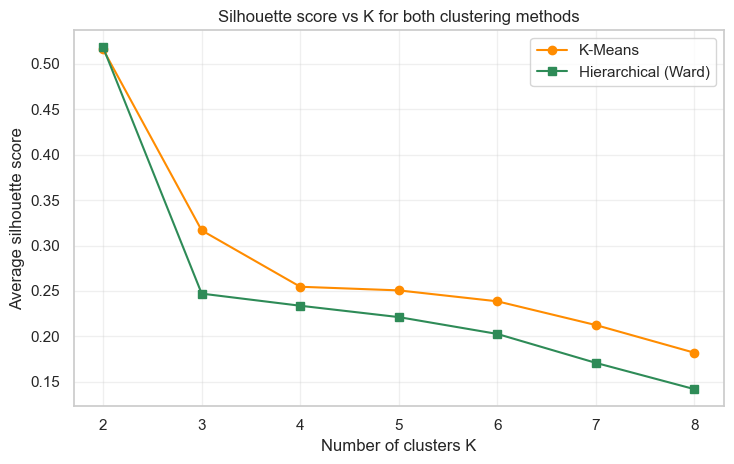

In [38]:
# Silhouette scores for K-Means and for Ward hierarchical clustering, K = 2..8, SAME feature space
km_labels_by_k = {}
hc_labels_by_k = {}
sil_rows = []

for k in K_RANGE:
    km_labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_cluster)
    hc_labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_cluster)
    km_labels_by_k[k] = km_labels
    hc_labels_by_k[k] = hc_labels
    sil_rows.append({"K": k,
                     "kmeans_silhouette": silhouette_score(X_cluster, km_labels),
                     "hierarchical_silhouette": silhouette_score(X_cluster, hc_labels)})

silhouette_table = pd.DataFrame(sil_rows)
display(silhouette_table)

plt.figure(figsize=(7.5, 4.8))
plt.plot(silhouette_table["K"], silhouette_table["kmeans_silhouette"], marker="o", label="K-Means", color="darkorange")
plt.plot(silhouette_table["K"], silhouette_table["hierarchical_silhouette"], marker="s", label="Hierarchical (Ward)", color="seagreen")
plt.xlabel("Number of clusters K")
plt.ylabel("Average silhouette score")
plt.title("Silhouette score vs K for both clustering methods")
plt.xticks(K_RANGE)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**How to read the output.** For each method, note which K has the highest average silhouette and how quickly the curve falls afterwards. Then ask: do the two methods give similar silhouette values at the same K? A large gap between the curves at some K means the two algorithms partition the data quite differently there. Remember the limitation above: the highest silhouette is not automatically the best segmentation.

*Your observation:* ______________________________

### 15.3 Selecting K (elbow + silhouette + cluster sizes + interpretability)

The table below puts the evidence side by side. The final choice must weigh (i) where the elbow flattens, (ii) which K has the best silhouette for each method, (iii) whether cluster sizes are usable (tiny clusters are hard to interpret and test), and (iv) whether the resulting groups make business sense. **If the elbow and the silhouette disagree, say so and explain your compromise; do not claim K is uniquely correct.**

In [39]:
def sizes_string(labels):
    counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    return " / ".join(str(c) for c in counts.values)

k_table = pd.DataFrame({
    "K": K_RANGE,
    "K-Means silhouette": silhouette_table["kmeans_silhouette"].values,
    "Hierarchical silhouette": silhouette_table["hierarchical_silhouette"].values,
    "Elbow observation": ["first K in the range" if np.isnan(p) else f"inertia {p:.1f}% lower than at K-1"
                          for p in elbow_table["pct_reduction_vs_previous_K"]],
})
display(k_table)

size_table = pd.DataFrame({
    "K": K_RANGE,
    "K-Means sizes (largest to smallest)": [sizes_string(km_labels_by_k[k]) for k in K_RANGE],
    "K-Means smallest cluster (%)": [100 * pd.Series(km_labels_by_k[k]).value_counts(normalize=True).min() for k in K_RANGE],
    "Hierarchical sizes (largest to smallest)": [sizes_string(hc_labels_by_k[k]) for k in K_RANGE],
    "Hierarchical smallest cluster (%)": [100 * pd.Series(hc_labels_by_k[k]).value_counts(normalize=True).min() for k in K_RANGE],
})
size_table

,K,K-Means silhouette,Hierarchical silhouette,Elbow observation
0,2,0.516,0.518,first K in the range
1,3,0.317,0.247,inertia 23.8% lower than at K-1
2,4,0.255,0.234,inertia 11.5% lower than at K-1
3,5,0.251,0.221,inertia 10.9% lower than at K-1
4,6,0.239,0.203,inertia 8.2% lower than at K-1
5,7,0.212,0.171,inertia 6.3% lower than at K-1
6,8,0.182,0.142,inertia 7.1% lower than at K-1


,K,K-Means sizes (largest to smallest),K-Means smallest cluster (%),Hierarchical sizes (largest to smallest),Hierarchical smallest cluster (%)
0,2,642 / 159,19.850,655 / 146,18.227
1,3,420 / 230 / 151,18.851,381 / 274 / 146,18.227
2,4,292 / 278 / 150 / 81,10.112,323 / 274 / 146 / 58,7.241
3,5,290 / 273 / 134 / 87 / 17,2.122,323 / 274 / 122 / 58 / 24,2.996
4,6,238 / 192 / 164 / 134 / 59 / 14,1.748,274 / 257 / 122 / 66 / 58 / 24,2.996
5,7,168 / 150 / 149 / 144 / 130 / 43 / 17,2.122,257 / 188 / 122 / 86 / 66 / 58 / 24,2.996
6,8,166 / 159 / 152 / 132 / 83 / 55 / 40 / 14,1.748,257 / 188 / 93 / 86 / 66 / 58 / 29 / 24,2.996


**How to read the output.**
1. *Candidate K from the elbow:* the K after which `Elbow observation` shows only small further reductions (if any).
2. *Candidate K from the silhouette:* the K with the highest value, for K-Means and for Hierarchical.
3. *Cluster sizes:* are any clusters very small? A tiny cluster may be a handful of extreme customers rather than a segment.
4. *Interpretability:* fewer clusters are simpler; more clusters give finer distinctions. You will inspect the profiles for your chosen K in Sections 16-17 and can come back and change K.

Fill in: elbow suggests **K = ___**; silhouette (K-Means) suggests **K = ___**; silhouette (Hierarchical) suggests **K = ___**; do they agree? ______; chosen K = ___ because ______________________.

# ==========================  DECISION 1: choose the number of clusters  ==========================
# Replace None by an integer between 2 and 8 AFTER studying Section 15.
SELECTED_K = 3

K_IS_PROVISIONAL = SELECTED_K == 3
if K_IS_PROVISIONAL:
    # Provisional placeholder so the notebook can run end-to-end: the K with the highest K-Means silhouette.
    SELECTED_K = int(k_table.loc[k_table["K-Means silhouette"].idxmax(), "K"])
    print("WARNING: SELECTED_K is PROVISIONAL (highest K-Means silhouette). Choose your own K using the evidence above.")

assert SELECTED_K in K_RANGE, "SELECTED_K must be one of the values in K_RANGE"
print("SELECTED_K =", SELECTED_K)

In [40]:
# ========================== DECISION 1: choose the number of clusters ==========================
SELECTED_K = 3

# Force provisional status to False so your choice is preserved
K_IS_PROVISIONAL = False

if K_IS_PROVISIONAL:
    SELECTED_K = int(k_table.loc[k_table["K-Means silhouette"].idxmax(), "K"])
    print(
        "WARNING: SELECTED_K is PROVISIONAL (highest K-Means silhouette)."
        " Choose your own K using the evidence above."
    )

assert SELECTED_K in K_RANGE, "SELECTED_K must be one of the values in K_RANGE"
print("SELECTED_K =", SELECTED_K)

SELECTED_K = 3


---
## 16. K-Means Clustering (final model)

**What / why:** we now fit K-Means with the chosen $K$, `n_init=10` and a fixed `random_state` (reproducible), then describe the clusters.

**Cluster numbering.** K-Means numbers clusters arbitrarily (0, 1, 2, ... has no meaning). To make results easier to read and to compare with the hierarchical method, we **renumber clusters in decreasing order of mean total profit** (cluster 0 = highest mean profit). This is only a relabelling; the partition itself is unchanged.

**Two kinds of "centre".**
* *Centroids in the scaled/transformed space* (what the algorithm uses). These are unit-free and **not** dollar values.
* *Group means of the ORIGINAL customer variables* (what we use for business interpretation). We deliberately do **not** inverse-transform the centroids: after log transformations, the back-transformed centroid is *not* the average of the original customers (a nonlinear function of a mean is not the mean of the function).

In [41]:
def relabel_by_profit(labels, profit):
    # Renumber clusters so that 0 = highest mean total_profit, 1 = next highest, ... (cosmetic only)
    labels = pd.Series(labels)
    mean_profit = profit.groupby(labels.values).mean().sort_values(ascending=False)
    mapping = {old: new for new, old in enumerate(mean_profit.index)}
    return labels.map(mapping).values


kmeans_final = KMeans(n_clusters=SELECTED_K, n_init=10, random_state=RANDOM_STATE)
kmeans_raw_labels = kmeans_final.fit_predict(X_cluster)
customers["kmeans_cluster"] = relabel_by_profit(kmeans_raw_labels, customers["total_profit"])

km_sizes = customers["kmeans_cluster"].value_counts().sort_index()
km_summary = pd.DataFrame({"n_customers": km_sizes, "pct_of_customers": 100 * km_sizes / km_sizes.sum()})
km_summary.index.name = "kmeans_cluster"
print("K-Means with K =", SELECTED_K, "| inertia =", round(kmeans_final.inertia_, 2),
      "| silhouette =", round(silhouette_score(X_cluster, customers["kmeans_cluster"]), 4))
km_summary

K-Means with K = 3 | inertia = 2199.1 | silhouette = 0.3167


C:\Users\Gulshan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,n_customers,pct_of_customers
kmeans_cluster,,
0,420,52.434
1,230,28.714
2,151,18.851


In [42]:
# Centroids in the SCALED / TRANSFORMED space (a K-Means centroid is the mean of its members' scaled values)
km_centers_scaled = X_cluster.groupby(customers["kmeans_cluster"]).mean()
print("K-Means centroids in the scaled/transformed space: unit-free numbers, NOT currency, NOT counts, NOT days")
display(km_centers_scaled)

# Group means and medians of the ORIGINAL variables (this is what we interpret in business terms)
print("\nMEAN of the ORIGINAL variables by K-Means cluster:")
display(customers.groupby("kmeans_cluster")[FINAL_FEATURES].mean())
print("MEDIAN of the ORIGINAL variables by K-Means cluster (robust to extreme customers):")
display(customers.groupby("kmeans_cluster")[FINAL_FEATURES].median())

K-Means centroids in the scaled/transformed space: unit-free numbers, NOT currency, NOT counts, NOT days


,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount
kmeans_cluster,,,,,,,
0,0.295,0.268,0.178,0.643,0.131,-0.331,-0.207
1,-0.982,-0.305,0.256,-0.538,-0.883,0.311,-0.227
2,-0.217,-3.740,-1.759,0.053,-0.257,-0.050,0.985



MEAN of the ORIGINAL variables by K-Means cluster:


,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount
kmeans_cluster,,,,,,,
0,"3,491.453",674.840,0.183,6.929,"1,023.531",111.490,0.110
1,962.655,172.749,0.198,3.387,585.361,332.609,0.108
2,"2,328.538",-396.601,-0.195,5.159,855.841,199.325,0.287


MEDIAN of the ORIGINAL variables by K-Means cluster (robust to extreme customers):


,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount
kmeans_cluster,,,,,,,
0,"2,825.471",443.971,0.180,7.000,"1,069.500",64.000,0.110
1,701.160,114.274,0.182,3.000,610.000,282.000,0.113
2,"1,730.266",-184.336,-0.112,5.000,919.000,103.000,0.263


**How to read the output.**
* Cluster sizes: are they reasonably balanced? Is any cluster very small?
* Scaled centroids show which features are *relatively* high (+) or low (-) for each cluster **compared with the typical customer**; they cannot be read as dollars.
* The **original-unit means and medians** show what the clusters look like in business terms. If a mean and median differ a lot within a cluster, extreme customers are influencing the mean.
* Do not name clusters yet; compare with the hierarchical solution first (Sections 17-19).

In [43]:
hier_model = AgglomerativeClustering(n_clusters=SELECTED_K, linkage="ward")
hier_raw_labels = hier_model.fit_predict(X_cluster)
customers["hier_cluster"] = relabel_by_profit(hier_raw_labels, customers["total_profit"])

hc_sizes = customers["hier_cluster"].value_counts().sort_index()
hc_summary = pd.DataFrame({"n_customers": hc_sizes, "pct_of_customers": 100 * hc_sizes / hc_sizes.sum()})
hc_summary.index.name = "hier_cluster"
print("Hierarchical (Ward) with K =", SELECTED_K,
      "| silhouette =", round(silhouette_score(X_cluster, customers["hier_cluster"]), 4))
display(hc_summary)

print("MEAN of the ORIGINAL variables by hierarchical cluster:")
display(customers.groupby("hier_cluster")[FINAL_FEATURES].mean())
print("MEDIAN of the ORIGINAL variables by hierarchical cluster:")
display(customers.groupby("hier_cluster")[FINAL_FEATURES].median())

Hierarchical (Ward) with K = 3 | silhouette = 0.2471


,n_customers,pct_of_customers
hier_cluster,,
0,274,34.207
1,381,47.566
2,146,18.227


MEAN of the ORIGINAL variables by hierarchical cluster:


,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount
hier_cluster,,,,,,,
0,"3,773.779",662.897,0.163,7.697,"1,087.558",75.916,0.124
1,"1,725.028",371.453,0.203,4.197,714.617,270.047,0.100
2,"2,384.788",-410.130,-0.201,5.205,845.808,203.664,0.290


MEDIAN of the ORIGINAL variables by hierarchical cluster:


,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount
hier_cluster,,,,,,,
0,"3,124.438",441.159,0.161,8.000,"1,096.000",37.500,0.124
1,"1,280.118",205.628,0.187,4.000,750.000,206.000,0.097
2,"1,771.713",-190.251,-0.123,5.000,912.000,104.500,0.266


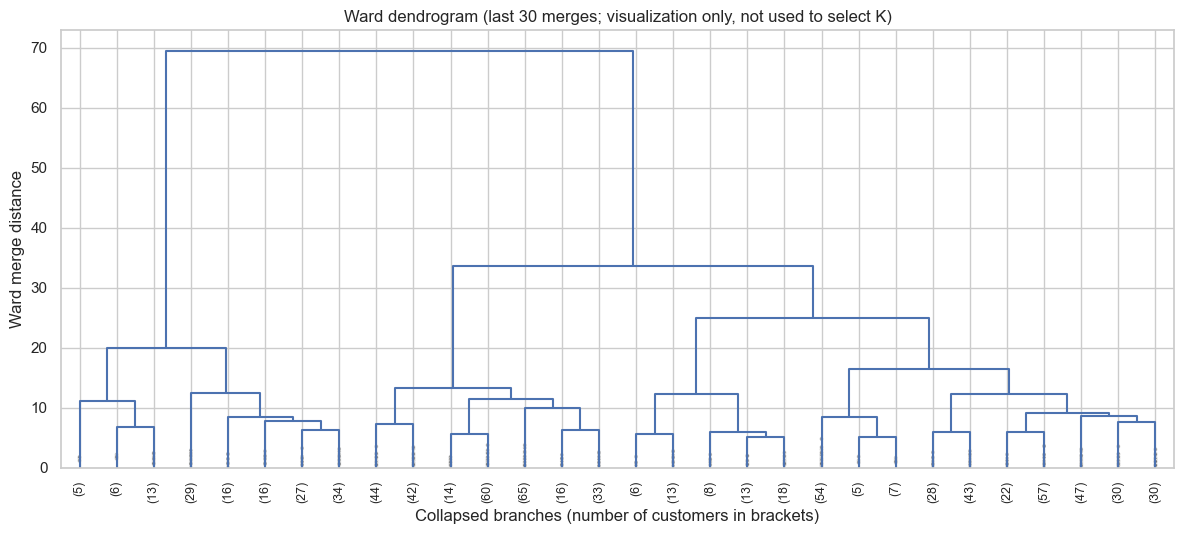

ARI between scipy-Ward and scikit-learn-Ward partitions (expect 1.0): 1.0


In [44]:
# Dendrogram (visualization only; NOT used to choose K).  color_threshold=0 -> single colour, so no cut is suggested.
Z_ward = linkage(X_cluster.values, method="ward")

plt.figure(figsize=(12, 5.5))
dendrogram(Z_ward, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9,
           show_contracted=True, color_threshold=0)
plt.title("Ward dendrogram (last 30 merges; visualization only, not used to select K)")
plt.xlabel("Collapsed branches (number of customers in brackets)")
plt.ylabel("Ward merge distance")
plt.tight_layout()
plt.show()

# Consistency check: scipy's Ward tree, cut into K clusters, should reproduce scikit-learn's Ward partition
scipy_labels = fcluster(Z_ward, t=SELECTED_K, criterion="maxclust")
print("ARI between scipy-Ward and scikit-learn-Ward partitions (expect 1.0):",
      round(adjusted_rand_score(scipy_labels, hier_raw_labels), 4))

**How to read the output.**
* Compare cluster sizes with K-Means. Ward tends to produce clusters of more similar size than average/complete linkage.
* On the dendrogram, the height of a merge is the increase in within-cluster variance it causes. Very tall merges near the top join groups that are far apart; many short merges at the bottom mean many similar customers. **Do not choose K from the tree**, since K-selection is restricted to the elbow and the silhouette.
* The ARI printed at the end is only a software consistency check (two implementations of the same algorithm), not an evaluation metric.

---
## 18. K-Means vs Hierarchical Comparison

**What / why:** the two methods are compared on the **same features and the same K** using several criteria. We do not pick a method just because its silhouette is slightly higher.

**Separation measure.** To compare *how well each solution separates customers on each dimension* we use the **epsilon-squared ($\varepsilon^2$) effect size of a Kruskal-Wallis test** of that variable across clusters (it is rank-based, so robust to skew): $\varepsilon^2 = H/(n-1)$, where $H$ is the Kruskal-Wallis statistic. It ranges from 0 (no separation) to 1 (perfect separation). It is used here as a *descriptive size of between-cluster difference*, not as a hypothesis test.

Rows that need judgement (interpretability) or later analysis (stability) are filled after Sections 22 and 24.

In [45]:
def kruskal_epsilon2(values, labels):
    # epsilon-squared effect size for a Kruskal-Wallis test: H / (n - 1)
    groups = [values[labels == c] for c in sorted(labels.unique())]
    H, p = stats.kruskal(*groups)
    return H / (len(values) - 1)


def separation_text(cluster_col, features):
    return " | ".join(f"{f}: {kruskal_epsilon2(customers[f], customers[cluster_col]):.2f}" for f in features)


comparison = pd.DataFrame(index=["K", "Silhouette score", "Cluster sizes (largest to smallest)", "Smallest cluster (% of customers)",
                                 "Profitability separation (epsilon-squared)", "Sales separation (epsilon-squared)",
                                 "Activity separation (epsilon-squared)", "Discount separation (epsilon-squared)",
                                 "Interpretability", "Stability"],
                          columns=["K-Means", "Hierarchical"], dtype=object)

for name, col in [("K-Means", "kmeans_cluster"), ("Hierarchical", "hier_cluster")]:
    comparison.loc["K", name] = SELECTED_K
    comparison.loc["Silhouette score", name] = f"{silhouette_score(X_cluster, customers[col]):.3f}"
    comparison.loc["Cluster sizes (largest to smallest)", name] = sizes_string(customers[col])
    comparison.loc["Smallest cluster (% of customers)", name] = f"{100 * customers[col].value_counts(normalize=True).min():.1f}"
    comparison.loc["Profitability separation (epsilon-squared)", name] = separation_text(col, ["total_profit", "profit_margin"])
    comparison.loc["Sales separation (epsilon-squared)", name] = separation_text(col, ["total_sales"])
    comparison.loc["Activity separation (epsilon-squared)", name] = separation_text(col, ["n_orders", "tenure_days", "recency_days"])
    comparison.loc["Discount separation (epsilon-squared)", name] = separation_text(col, ["weighted_discount"])
    comparison.loc["Interpretability", name] = "(fill in after reading the profiles in Sections 16-17 and 22)"
    comparison.loc["Stability", name] = "(filled automatically in Section 24)"

pd.set_option("display.max_colwidth", 120)
comparison

,K-Means,Hierarchical
K,3,3
Silhouette score,0.317,0.247
Cluster sizes (largest to smallest),420 / 230 / 151,381 / 274 / 146
Smallest cluster (% of customers),18.9,18.2
Profitability separation (epsilon-squared),total_profit: 0.62 | profit_margin: 0.46,total_profit: 0.50 | profit_margin: 0.46
Sales separation (epsilon-squared),total_sales: 0.37,total_sales: 0.22
Activity separation (epsilon-squared),n_orders: 0.45 | tenure_days: 0.32 | recency_days: 0.21,n_orders: 0.43 | tenure_days: 0.29 | recency_days: 0.23
Discount separation (epsilon-squared),weighted_discount: 0.35,weighted_discount: 0.36
Interpretability,(fill in after reading the profiles in Sections 16-17 and 22),(fill in after reading the profiles in Sections 16-17 and 22)
Stability,(filled automatically in Section 24),(filled automatically in Section 24)


**How to read the output.** For each row compare the two columns. In the separation rows, *larger* $\varepsilon^2$ means the clusters differ more on that variable. Ask: does one method separate profitability much better? Does one method give a tiny cluster the other does not? Rows marked "(fill in...)" are for your judgement after inspecting the profiles. **No winner is declared by this table**: it is evidence for the decision in Section 19.

### 18.2 Do the two methods assign customers to the same groups?

The **cross-tabulation** counts customers by (K-Means cluster, Hierarchical cluster). If both methods discovered the same structure, most customers would sit in one cell per row. Because clusters are numbered by decreasing mean profit in both methods, matching clusters tend to sit near the diagonal, but that is a convenience, not a guarantee.

The **Adjusted Rand Index (ARI)** is reported *only to describe agreement* (1 = identical partitions, about 0 = chance-level agreement). It is **not** used to select K and **not** used as the sole criterion for choosing between the algorithms.

Counts of customers:


Hierarchical cluster,0,1,2,All
K-Means cluster,,,,
0,271,149,0,420
1,1,229,0,230
2,2,3,146,151
All,274,381,146,801


Row percentages (share of each K-Means cluster falling in each hierarchical cluster):


Hierarchical cluster,0,1,2
K-Means cluster,,,
0,64.524,35.476,0.000
1,0.435,99.565,0.000
2,1.325,1.987,96.689


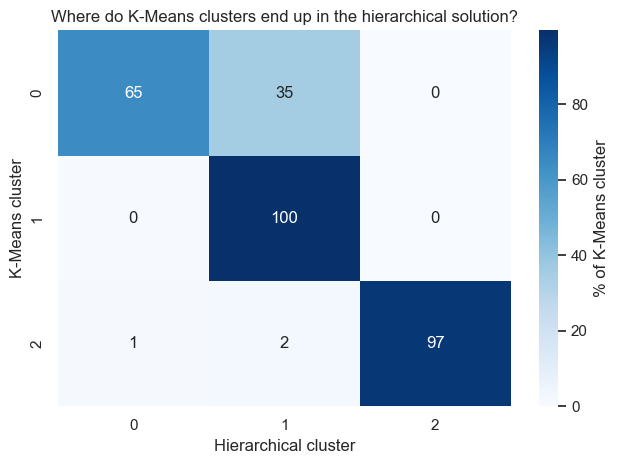

Adjusted Rand Index between the two partitions (descriptive only): 0.489

For each K-Means cluster: % of its customers that fall in its single most common hierarchical cluster:


,percent
K-Means cluster,
0,64.500
1,99.600
2,96.700


In [46]:
crosstab_counts = pd.crosstab(customers["kmeans_cluster"], customers["hier_cluster"],
                              rownames=["K-Means cluster"], colnames=["Hierarchical cluster"], margins=True)
print("Counts of customers:")
display(crosstab_counts)

crosstab_row_pct = 100 * pd.crosstab(customers["kmeans_cluster"], customers["hier_cluster"],
                                     rownames=["K-Means cluster"], colnames=["Hierarchical cluster"], normalize="index")
print("Row percentages (share of each K-Means cluster falling in each hierarchical cluster):")
display(crosstab_row_pct)

plt.figure(figsize=(6.5, 4.8))
sns.heatmap(crosstab_row_pct, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of K-Means cluster"})
plt.title("Where do K-Means clusters end up in the hierarchical solution?")
plt.tight_layout()
plt.show()

ari_methods = adjusted_rand_score(customers["kmeans_cluster"], customers["hier_cluster"])
print("Adjusted Rand Index between the two partitions (descriptive only):", round(ari_methods, 3))
share_same_cell = crosstab_row_pct.max(axis=1)
print("\nFor each K-Means cluster: % of its customers that fall in its single most common hierarchical cluster:")
display(share_same_cell.round(1).to_frame("percent"))

**How to read the output.**
* Rows where one cell holds nearly 100% show a K-Means cluster that the hierarchical method reproduces almost exactly.
* Rows split across two or more cells show clusters whose boundaries differ between methods: look at which *neighbouring* clusters exchange customers (adjacent profit levels) and remember that boundary customers are the ambiguous ones.
* Because both methods rely on Euclidean variance-based logic, high agreement is expected to some degree; lower agreement means the data do not contain sharply separated, ball-shaped groups, and the segmentation should be described as *one reasonable partition*, not "the" segments.

*Your description of the overlap:* ______________________________

---
## 19. Final Method Selection

**What / why:** we now choose which segmentation to use for profiling, statistical validation and business interpretation. The choice must follow from the evidence gathered so far and **not** from a pre-decided favourite. Evaluate, in this order:

1. **Silhouette evidence** (Section 15.2 and the comparison table).
2. **Cluster sizes** (usable, or is any cluster tiny?).
3. **Profitability separation** (does the solution cleanly separate profitable from loss-making customers?).
4. **Behavioral separation** (sales, activity, discount).
5. **Interpretability** (do the profiles tell a coherent story?).
6. **Stability** (Section 24; you can revisit this decision after seeing it).
7. **Business relevance.**

Legitimate conclusions include: K-Means is more suitable; hierarchical is more suitable; both give broadly similar segmentation (then either may be used, and you say so); or the methods reveal different but meaningful structure (then discuss both). Explain **the specific evidence** for your choice; do not write "best algorithm" without it.

*Your reasoning (fill in):* ______________________________

In [47]:
# ==========================  DECISION 2: choose the method used for profiling and interpretation  ==========================
# Replace None by "kmeans" or "hierarchical" AFTER reading Sections 15-18 (and revisit after Section 24).
FINAL_METHOD = "kmeans"

METHOD_IS_PROVISIONAL = FINAL_METHOD == "kmeans"
if METHOD_IS_PROVISIONAL:
    FINAL_METHOD = "kmeans"     # provisional placeholder ONLY so the remaining sections can run; NOT a conclusion

assert FINAL_METHOD in ("kmeans", "hierarchical"), "FINAL_METHOD must be 'kmeans' or 'hierarchical'"

if FINAL_METHOD == "kmeans":
    customers["final_cluster"] = customers["kmeans_cluster"]
    FINAL_METHOD_NAME = "K-Means"
else:
    customers["final_cluster"] = customers["hier_cluster"]
    FINAL_METHOD_NAME = "Hierarchical (Ward)"

final_labels = customers["final_cluster"]
CLUSTER_IDS = sorted(final_labels.unique())
CLUSTER_COLORS = dict(zip(CLUSTER_IDS, sns.color_palette("tab10", n_colors=len(CLUSTER_IDS))))

print("Final segmentation:", FINAL_METHOD_NAME, "| K =", SELECTED_K)
print("Cluster sizes:", final_labels.value_counts().sort_index().to_dict())

Final segmentation: K-Means | K = 3
Cluster sizes: {0: 420, 1: 230, 2: 151}


---
## 20. Multidimensional Cluster Representation

**What / why:** we clustered in a 7-dimensional space, but a single 2D plot shows only two of those dimensions. We therefore look at the final clusters (Section 19) through several *complementary* views. Each answers a specific question:

| View | Question it answers |
|---|---|
| A. Pairwise scatter plots | For which *pairs* of features do the clusters separate, and for which do they overlap? |
| B. Parallel coordinates | What does each cluster's *whole profile* across all 7 features look like, and where do clusters overlap on a given feature? |
| C. Standardised profile heatmap | Which features are relatively high/low for each cluster? |
| D. Boxplots | How do the *distributions* (not just averages) of key variables differ across clusters? |
| E. Profit vs sales | Do clusters separate customers with similar sales but different profit? |

**Concept: multidimensional representation.** No single picture shows all dimensions faithfully, so we combine several. The plots below use the **scaled clustering space** (A, B) because that is where distances were computed, and **original units** (C-E) because that is where business meaning lives. None of these plots is used to select K.

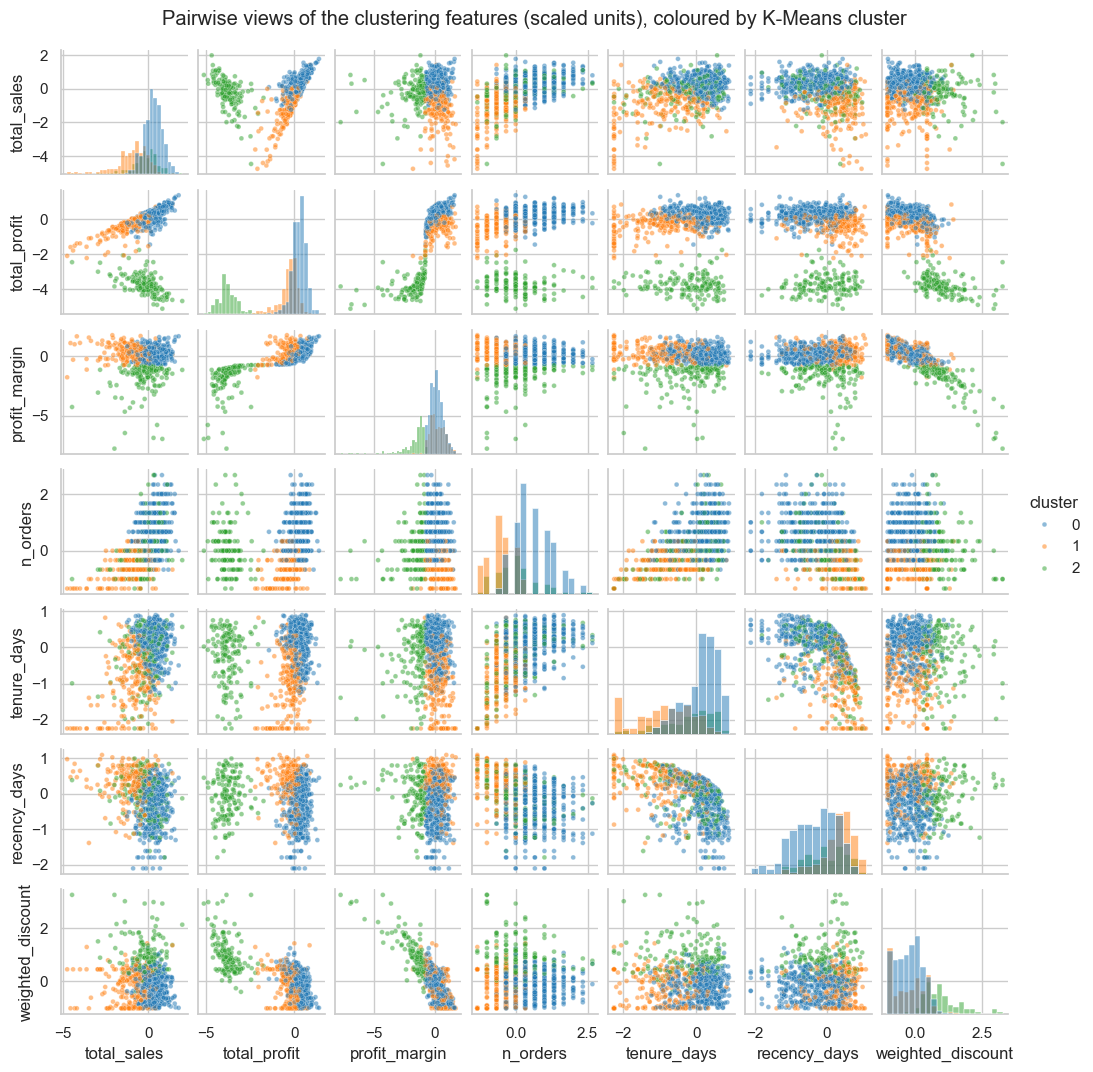

In [48]:
# A. Pairwise scatter plots in the clustering space (each point = one customer, colour = final cluster)
plot_df = X_cluster.copy()
plot_df["cluster"] = final_labels.values

sns.pairplot(plot_df, vars=FINAL_FEATURES, hue="cluster", palette=CLUSTER_COLORS,
             diag_kind="hist", plot_kws={"alpha": 0.5, "s": 12}, height=1.5)
plt.gcf().suptitle(f"Pairwise views of the clustering features (scaled units), coloured by {FINAL_METHOD_NAME} cluster", y=1.02)
plt.show()

**How to read the output.** Each panel is a 2D slice of the 7D space; the diagonal shows each feature's distribution by cluster. Look for panels where clusters form *separate clouds* (that pair of features distinguishes them) and panels where colours are mixed (it does not). A cluster that overlaps another in most panels is not sharply distinct. Axes are scaled units, not dollars.

# B. Parallel coordinates: one line per customer across all clustering features, thick line = cluster median
fig, ax = plt.subplots(figsize=(12, 6))
x_positions = np.arange(len(FINAL_FEATURES))

for c in CLUSTER_IDS:
    members = X_cluster[final_labels == c]
    ax.plot(x_positions, members.values.T, color=CLUSTER_COLORS[c], alpha=0.10, linewidth=0.8)   # every customer
for c in CLUSTER_IDS:
    members = X_cluster[final_labels == c]
    ax.plot(x_positions, members.median().values, color=CLUSTER_COLORS[c], linewidth=3.5, marker="o",
            label=f"Cluster {c} (median, n={len(members)})")

ax.set_xticks(x_positions)
ax.set_xticklabels(FINAL_FEATURES, rotation=20)
ax.set_ylabel("Scaled value (unit-free)")
ax.set_title(f"Parallel coordinates of the final clustering features ({FINAL_METHOD_NAME}, K = {SELECTED_K})")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

**How to read the output.** Each thin line is one customer traced across the 7 features; thick lines are cluster medians. Where the thick lines are far apart *and* the thin bundles do not intermingle, that feature separates the clusters. Where bundles cross and mix, clusters overlap on that feature. A cluster whose median line is high on one feature and low on another has a distinctive *profile* (for example, high on sales but low on margin). Values are scaled, so read *relative* position, not dollars.

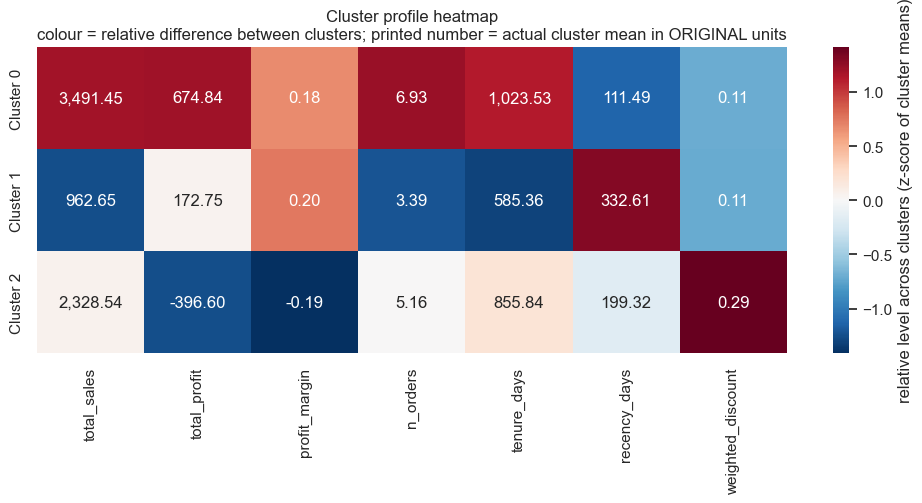

In [49]:
# C. Standardised cluster-profile heatmap
cluster_means = customers.groupby("final_cluster")[FINAL_FEATURES].mean()          # ORIGINAL units
spread_between_clusters = cluster_means.std(ddof=0).replace(0, np.nan)
profile_z = (cluster_means - cluster_means.mean()) / spread_between_clusters        # for VISUALISATION only

annotations = np.array([[f"{v:,.2f}" for v in row] for row in cluster_means.values])   # actual means as text

plt.figure(figsize=(10, 0.9 * len(cluster_means) + 2.5))
sns.heatmap(profile_z, annot=annotations, fmt="", cmap="RdBu_r", center=0,
            yticklabels=[f"Cluster {c}" for c in cluster_means.index], cbar_kws={"label": "relative level across clusters (z-score of cluster means)"})
plt.title("Cluster profile heatmap\ncolour = relative difference between clusters; printed number = actual cluster mean in ORIGINAL units")
plt.ylabel("")
plt.tight_layout()
plt.show()

**How to read the output.** *Colour* shows how a cluster's mean compares with the other clusters' means **for that feature only** (red = relatively high, blue = relatively low; it is standardised for visualization). The *printed numbers* are the actual means in original units (dollars, orders, days, discount rate). The heatmap shows **relative** differences; do not read the colours as currency. Use it to summarise, in one picture, what makes each cluster different.

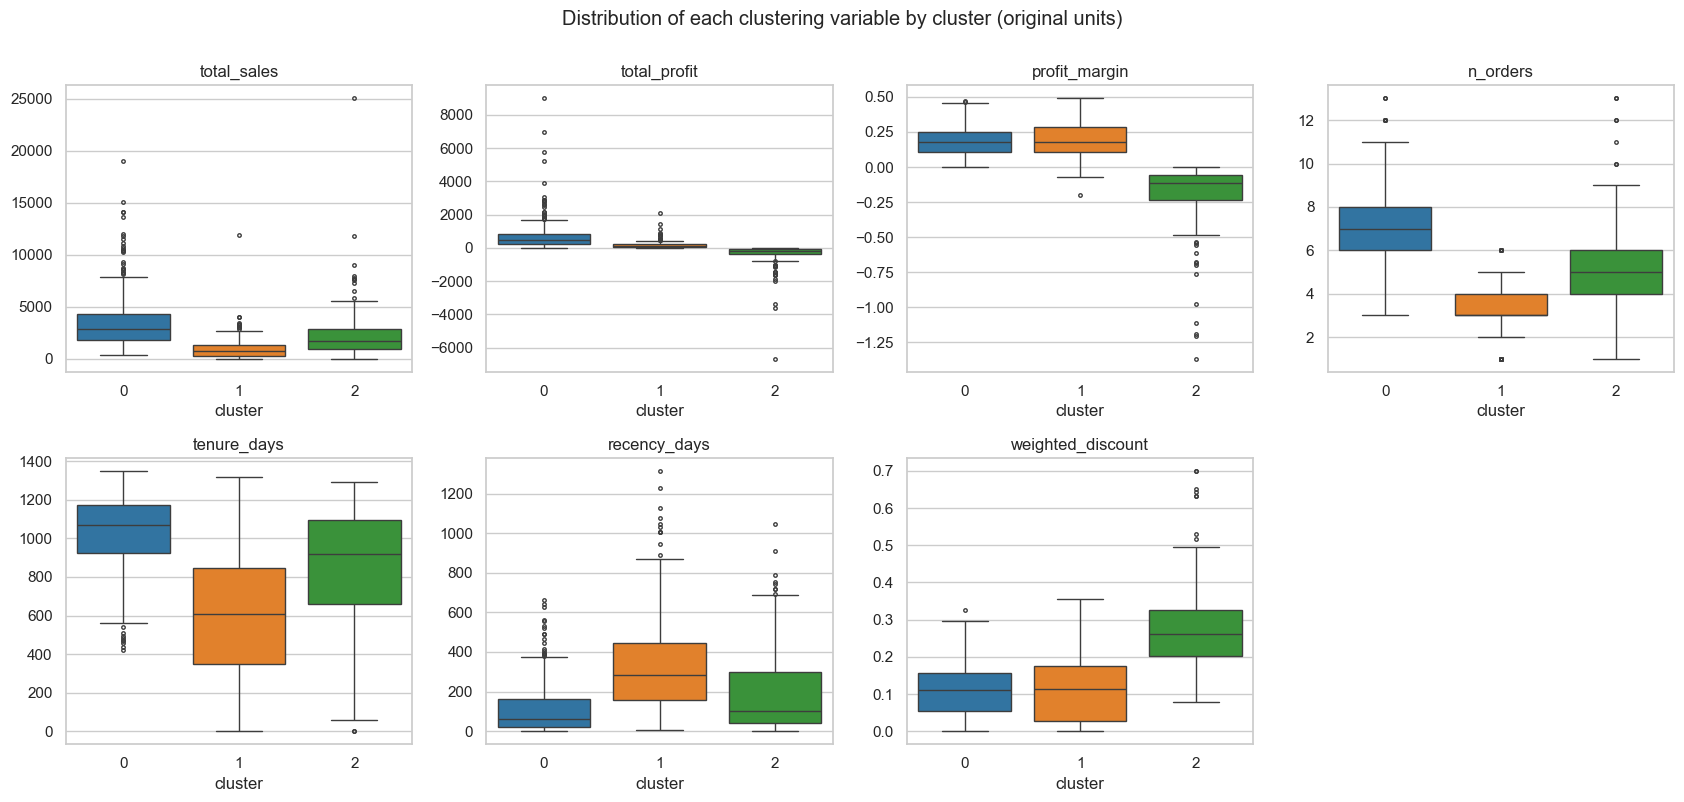

In [50]:
# D. Distributions of the clustering variables by cluster (ORIGINAL units)
box_df = customers[FINAL_FEATURES + ["final_cluster"]]
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.flatten()
for i, col in enumerate(FINAL_FEATURES):
    sns.boxplot(data=box_df, x="final_cluster", y=col, hue="final_cluster", palette=CLUSTER_COLORS,
                legend=False, ax=axes[i], fliersize=2.5)
    axes[i].set_title(col)
    axes[i].set_xlabel("cluster")
    axes[i].set_ylabel("")
fig.delaxes(axes[-1])
fig.suptitle("Distribution of each clustering variable by cluster (original units)", y=1.00)
plt.tight_layout()
plt.show()

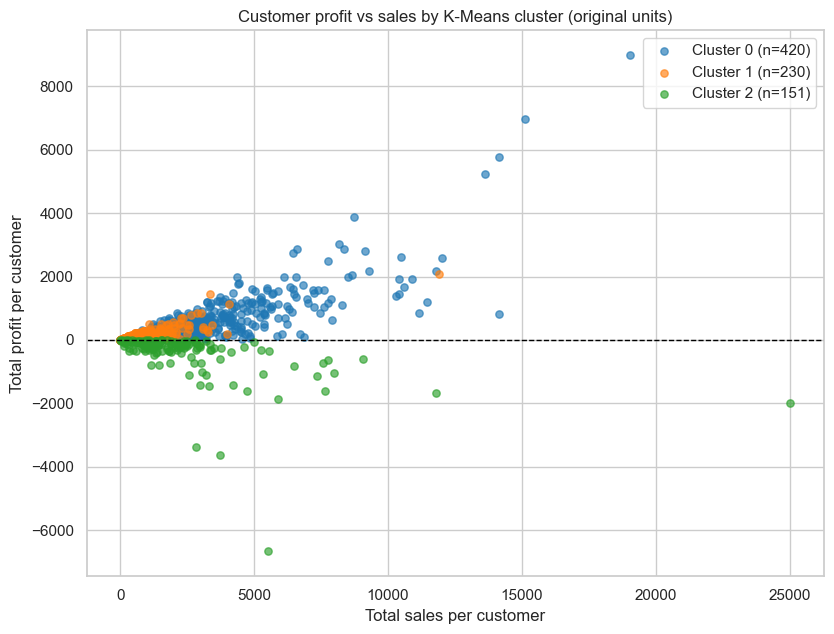

In [51]:
# E. Profit vs sales, coloured by the final cluster (original units)
plt.figure(figsize=(8.5, 6.5))
for c in CLUSTER_IDS:
    members = customers[final_labels == c]
    plt.scatter(members["total_sales"], members["total_profit"], s=28, alpha=0.65, color=CLUSTER_COLORS[c],
                label=f"Cluster {c} (n={len(members)})")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Total sales per customer")
plt.ylabel("Total profit per customer")
plt.title(f"Customer profit vs sales by {FINAL_METHOD_NAME} cluster (original units)")
plt.legend()
plt.tight_layout()
plt.show()

**How to read the output.**
* *Boxplots:* compare the medians (centre lines) and the overlap of boxes across clusters. Boxes that barely overlap indicate strong differences; heavy overlap indicates weak differences on that variable.
* *Profit vs sales:* look for clusters that occupy different profit levels at *similar* sales levels (this shows why clustering on sales alone would miss profitability), and for clusters located below the zero-profit line.
* Neither plot proves a cause; they show how the groups differ.

---
## 21. PCA Visualization

**What / why:** to see all clustering information in 2 or 3 dimensions we use **Principal Component Analysis (PCA)**.

**Concept.** PCA constructs new axes (principal components) as **linear combinations of the original features**. PC1 is the direction of greatest variance, PC2 the next greatest direction *orthogonal* to PC1, and so on. The **explained variance ratio** of a component is the share of total variance it captures.

> **Key distinction.** *PCA reduces the dimensionality of the feature space for visualization. It does not mean that clustering was performed using only the first two principal components.* Both K-Means and Ward were run on the full 7-feature scaled matrix `X_cluster`. PCA is applied afterwards, to draw the result.

A 2D or 3D PCA plot is a **projection**: it shows only the directions of greatest variance and hides the rest. Clusters that overlap in the plot may be separated in the hidden dimensions, and clusters that look separated in the plot are not thereby *proven* separated in the original space.

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.552,0.552
1,PC2,0.233,0.785
2,PC3,0.074,0.858
3,PC4,0.055,0.913
4,PC5,0.038,0.951
5,PC6,0.031,0.982
6,PC7,0.018,1.000


Loadings: how each ORIGINAL (scaled) feature contributes to the first three components


,PC1,PC2,PC3
total_sales,0.124,0.601,0.626
total_profit,0.800,-0.045,0.171
profit_margin,0.484,-0.198,-0.238
n_orders,0.107,0.538,-0.130
tenure_days,0.059,0.464,-0.471
recency_days,-0.039,-0.276,0.519
weighted_discount,-0.306,0.128,0.121


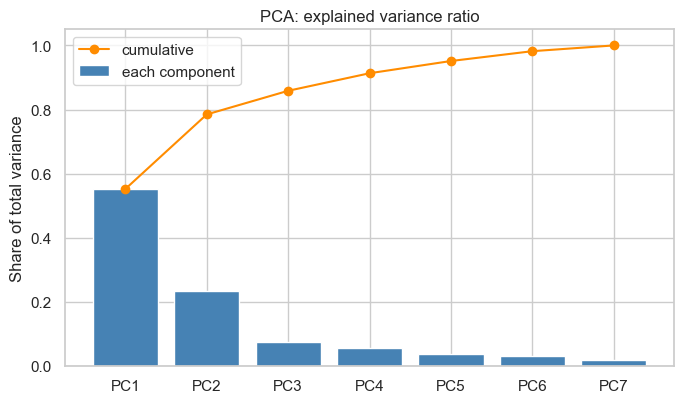

In [52]:
# PCA on the FINAL scaled clustering matrix (for visualization ONLY; clustering was already done on X_cluster)
pca_full = PCA(random_state=RANDOM_STATE)
pc_scores = pca_full.fit_transform(X_cluster)

explained = pca_full.explained_variance_ratio_
pca_table = pd.DataFrame({"component": [f"PC{i + 1}" for i in range(len(explained))],
                          "explained_variance_ratio": explained,
                          "cumulative_explained_variance": np.cumsum(explained)})
display(pca_table)

print("Loadings: how each ORIGINAL (scaled) feature contributes to the first three components")
display(pd.DataFrame(pca_full.components_[:3].T, index=FINAL_FEATURES, columns=["PC1", "PC2", "PC3"]))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(pca_table["component"], pca_table["explained_variance_ratio"], color="steelblue", label="each component")
ax.plot(pca_table["component"], pca_table["cumulative_explained_variance"], color="darkorange", marker="o", label="cumulative")
ax.set_ylabel("Share of total variance")
ax.set_title("PCA: explained variance ratio")
ax.legend()
plt.tight_layout()
plt.show()

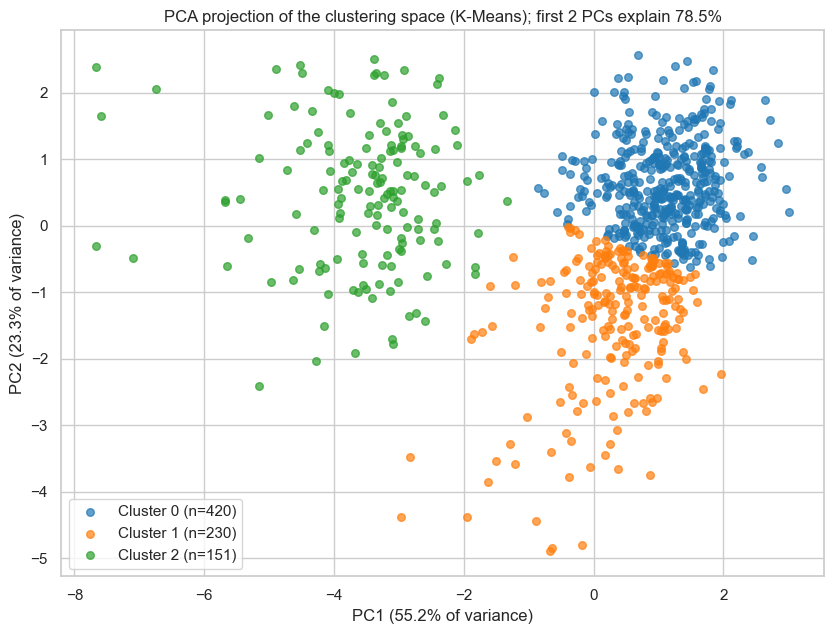

In [53]:
# 2D PCA plot (first two components), coloured by the final cluster
plt.figure(figsize=(8.5, 6.5))
for c in CLUSTER_IDS:
    mask = (final_labels == c).values
    plt.scatter(pc_scores[mask, 0], pc_scores[mask, 1], s=30, alpha=0.7, color=CLUSTER_COLORS[c], label=f"Cluster {c} (n={mask.sum()})")
plt.xlabel(f"PC1 ({explained[0]:.1%} of variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} of variance)")
plt.title(f"PCA projection of the clustering space ({FINAL_METHOD_NAME}); first 2 PCs explain {explained[:2].sum():.1%}")
plt.legend()
plt.tight_layout()
plt.show()

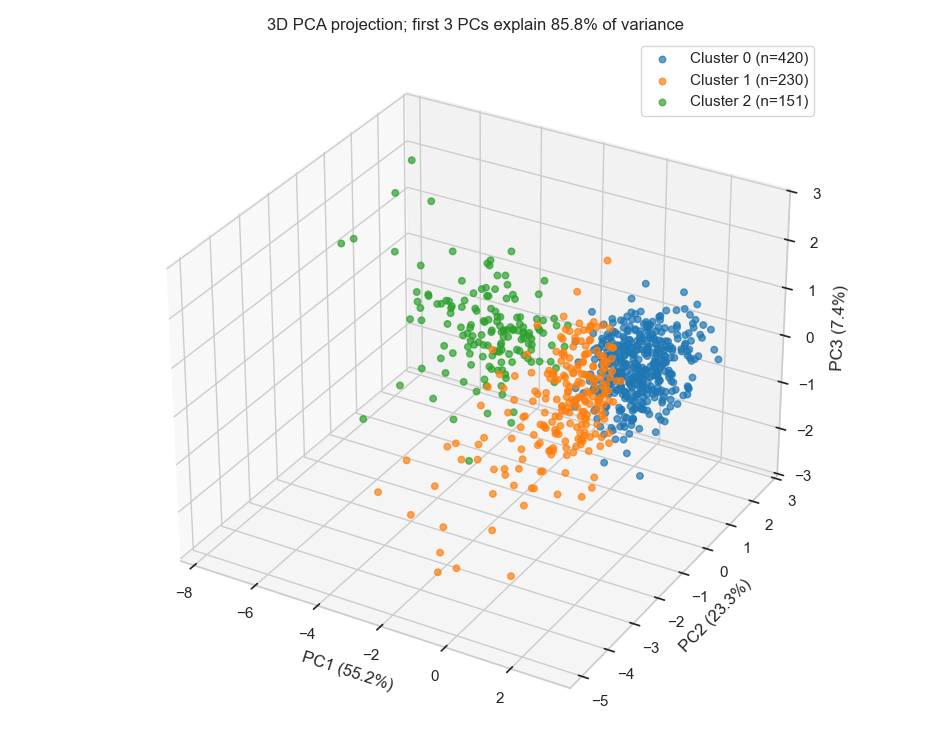

In [54]:
# 3D PCA plot (first three components); computationally light for a few hundred customers
%matplotlib widget
fig = plt.figure(figsize=(9.5, 7.5))
ax = fig.add_subplot(111, projection="3d")
for c in CLUSTER_IDS:
    mask = (final_labels == c).values
    ax.scatter(pc_scores[mask, 0], pc_scores[mask, 1], pc_scores[mask, 2], s=22, alpha=0.7,
               color=CLUSTER_COLORS[c], label=f"Cluster {c} (n={mask.sum()})")
ax.set_xlabel(f"PC1 ({explained[0]:.1%})")
ax.set_ylabel(f"PC2 ({explained[1]:.1%})")
ax.set_zlabel(f"PC3 ({explained[2]:.1%})")
ax.set_title(f"3D PCA projection; first 3 PCs explain {explained[:3].sum():.1%} of variance")
ax.legend()
plt.tight_layout()
plt.show()
# Tip: run  %matplotlib widget  (needs ipympl) or  %matplotlib notebook  BEFORE this cell to rotate the plot with the mouse.

**How to read the output.**
* *Explained variance:* the cumulative value for 2 and for 3 components tells you how much of the 7-dimensional structure each picture retains. The lower it is, the more the plot hides; interpret overlap in the plot with that in mind.
* *Loadings:* they tell you what PC1, PC2, PC3 *mean* (which original features they combine). A component dominated by profit and sales is a "value" axis, for example.
* *Plots:* look at whether clusters occupy different regions and where they overlap. Overlap in a projection is not proof of overlap in the full space; separation is not proof of complete separation.

---
## 22. Cluster Profiling

**What / why:** the goal is to understand **what each cluster represents in business terms**. All figures are computed from the **original customer-level variables** for the *final* segmentation chosen in Section 19.

**Two ways to compute a "profit margin" for a cluster**
* `pooled_profit_margin` = (sum of the cluster's profit) / (sum of the cluster's sales): the margin the business earns *on that cluster as a whole*.
* `avg_customer_profit_margin` = mean of the individual customers' margins: the *typical customer's* margin (each customer counts equally).
They answer different questions, so both are shown.

In [55]:
grp = customers.groupby("final_cluster")

profile = pd.DataFrame({
    "customers": grp.size(),
    "pct_of_customers": 100 * grp.size() / len(customers),
    "total_sales": grp["total_sales"].sum(),
    "total_profit": grp["total_profit"].sum(),
    "pct_of_all_sales": 100 * grp["total_sales"].sum() / customers["total_sales"].sum(),
    "pct_of_all_profit": 100 * grp["total_profit"].sum() / customers["total_profit"].sum(),
    "avg_sales_per_customer": grp["total_sales"].mean(),
    "avg_profit_per_customer": grp["total_profit"].mean(),
    "avg_orders": grp["n_orders"].mean(),
    "avg_order_value (mean of customers)": grp["avg_order_value"].mean(),
    "avg_quantity": grp["total_quantity"].mean(),
    "avg_discount (simple)": grp["avg_discount"].mean(),
    "avg_weighted_discount": grp["weighted_discount"].mean(),
    "pooled_profit_margin": grp["total_profit"].sum() / grp["total_sales"].sum(),
    "avg_customer_profit_margin": grp["profit_margin"].mean(),
    "avg_tenure_days": grp["tenure_days"].mean(),
    "avg_recency_days": grp["recency_days"].mean(),
})
profile.index.name = "cluster"
print(f"Cluster profiles: {FINAL_METHOD_NAME}, K = {SELECTED_K}")
profile.T

Cluster profiles: K-Means, K = 3


cluster,0,1,2
customers,420.000,230.000,151.000
pct_of_customers,52.434,28.714,18.851
total_sales,"1,466,410.148","221,410.612","351,609.274"
total_profit,"283,432.733","39,732.325","-59,886.705"
pct_of_all_sales,71.903,10.856,17.241
pct_of_all_profit,107.655,15.091,-22.747
avg_sales_per_customer,"3,491.453",962.655,"2,328.538"
avg_profit_per_customer,674.840,172.749,-396.601
avg_orders,6.929,3.387,5.159
avg_order_value (mean of customers),524.450,306.315,471.592


In [56]:
# Medians: robust summaries (less affected by extreme customers than means)
print("MEDIAN of the clustering variables by cluster (original units):")
display(grp[FINAL_FEATURES].median())

# Relative position of each cluster on each variable: rank 1 = highest cluster mean
means = grp[FINAL_FEATURES].mean()
print("Rank of each cluster's MEAN on each feature (1 = highest mean among clusters):")
display(means.rank(ascending=False).astype(int))

# Data-driven description: which features is each cluster highest / lowest on?
for c in means.index:
    highest = [f for f in FINAL_FEATURES if means[f].idxmax() == c]
    lowest = [f for f in FINAL_FEATURES if means[f].idxmin() == c]
    print(f"Cluster {c}: highest mean on {highest if highest else 'none'} | lowest mean on {lowest if lowest else 'none'}")

MEDIAN of the clustering variables by cluster (original units):


,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount
cluster,,,,,,,
0,"2,825.471",443.971,0.180,7.000,"1,069.500",64.000,0.110
1,701.160,114.274,0.182,3.000,610.000,282.000,0.113
2,"1,730.266",-184.336,-0.112,5.000,919.000,103.000,0.263


Rank of each cluster's MEAN on each feature (1 = highest mean among clusters):


,total_sales,total_profit,profit_margin,n_orders,tenure_days,recency_days,weighted_discount
cluster,,,,,,,
0,1,1,2,1,1,3,2
1,3,2,1,3,3,1,3
2,2,3,3,2,2,2,1


Cluster 0: highest mean on ['total_sales', 'total_profit', 'n_orders', 'tenure_days'] | lowest mean on ['recency_days']
Cluster 1: highest mean on ['profit_margin', 'recency_days'] | lowest mean on ['total_sales', 'n_orders', 'tenure_days', 'weighted_discount']
Cluster 2: highest mean on ['weighted_discount'] | lowest mean on ['total_profit', 'profit_margin']


In [57]:
# Segment composition (Segment was NOT used for clustering; here it only DESCRIBES the clusters)
segment_mix = 100 * pd.crosstab(customers["final_cluster"], customers["segment"], normalize="index")
print("Share (%) of each cluster's customers belonging to each Segment:")
display(segment_mix)
print("Overall Segment mix (%), for comparison:")
display((100 * customers["segment"].value_counts(normalize=True)).to_frame("percent").T)

Share (%) of each cluster's customers belonging to each Segment:


segment,Consumer,Corporate,Home Office
final_cluster,,,
0,51.429,30.714,17.857
1,50.870,28.696,20.435
2,53.642,29.139,17.219


Overall Segment mix (%), for comparison:


segment,Consumer,Corporate,Home Office
percent,51.685,29.838,18.477


**How to read the output.**
* *Share columns:* a small cluster can still carry a large share of total profit (or of losses). Compare `pct_of_customers` with `pct_of_all_sales` and `pct_of_all_profit`.
* *Means vs medians:* large differences signal that extreme customers influence the mean.
* *Ranks and highest/lowest lists:* use them as an objective starting point for describing each cluster.
* *Segment mix:* if a cluster's Segment mix is close to the overall mix, `Segment` does not distinguish it; if it differs, mention it as a descriptive observation (not a cause).

Now write **neutral descriptive labels** based on what you observe (e.g. "High-profit / high-activity customers", "High-sales / low-margin customers", "Low-activity / high-discount customers"). Avoid subjective words such as "best" or "worst" unless the data clearly support them.

In [58]:
# Fill in a neutral, descriptive label for each cluster AFTER studying the tables and plots above.
cluster_names = {
    # 0: "your descriptive label based on the observed profile",
    # 1: "...",
}

customers["cluster_name"] = final_labels.map(cluster_names)
customers["cluster_name"] = customers["cluster_name"].fillna("Cluster " + final_labels.astype(str))

for c in CLUSTER_IDS:
    print(f"Cluster {c}: {customers.loc[final_labels == c, 'cluster_name'].iloc[0]}")

Cluster 0: Cluster 0
Cluster 1: Cluster 1
Cluster 2: Cluster 2


---
## 25. Business Interpretation

**What / why:** we translate the statistical profile of each cluster into plain business language. The wording must stay **descriptive**:

* Use: *"customers in this cluster tend to..."*, *"this cluster is characterised by..."*, *"customers in this group have higher average..."*
* Do **not** write causal statements. Incorrect: *"Discounts cause lower profit."* Correct: *"This cluster has relatively high discount levels and relatively low profit margins."*

Clustering finds **patterns and associations**. It cannot show that one variable *causes* another; a high-discount cluster with low margins may reflect deal negotiation, product mix, competition, or factors not in this data set.

For **each** cluster, cover: profitability, sales, order activity/behavior, discount behavior, and customer characteristics (tenure, recency, Segment mix). The cell below prints the *facts*, computed from your results, so you can write accurate sentences.

In [59]:
if K_IS_PROVISIONAL or METHOD_IS_PROVISIONAL:
    print("NOTE: SELECTED_K and/or FINAL_METHOD are still PROVISIONAL placeholders (Sections 15.3 and 19).")
    print("      Make your own choices and re-run before writing your interpretation.\n")

print(f"Final segmentation: {FINAL_METHOD_NAME}, K = {SELECTED_K}\n")
for c in CLUSTER_IDS:
    r = profile.loc[c]
    print(f"--- Cluster {c}: {customers.loc[final_labels == c, 'cluster_name'].iloc[0]} ---")
    print(f"  Size          : {int(r['customers'])} customers ({r['pct_of_customers']:.1f}% of customers)")
    print(f"  Sales/profit  : {r['pct_of_all_sales']:.1f}% of all sales, {r['pct_of_all_profit']:.1f}% of all profit")
    print(f"  Per customer  : average sales {r['avg_sales_per_customer']:,.0f}, average profit {r['avg_profit_per_customer']:,.0f}")
    print(f"  Margin        : pooled {r['pooled_profit_margin']:.1%}; typical customer {r['avg_customer_profit_margin']:.1%}")
    print(f"  Discount      : sales-weighted average {r['avg_weighted_discount']:.1%}")
    print(f"  Activity      : {r['avg_orders']:.1f} orders on average; average order value {r['avg_order_value (mean of customers)']:,.0f}")
    print(f"  Timing        : average tenure {r['avg_tenure_days']:.0f} days; average recency {r['avg_recency_days']:.0f} days")
    print()

NOTE: SELECTED_K and/or FINAL_METHOD are still PROVISIONAL placeholders (Sections 15.3 and 19).
      Make your own choices and re-run before writing your interpretation.

Final segmentation: K-Means, K = 3

--- Cluster 0: Cluster 0 ---
  Size          : 420 customers (52.4% of customers)
  Sales/profit  : 71.9% of all sales, 107.7% of all profit
  Per customer  : average sales 3,491, average profit 675
  Margin        : pooled 19.3%; typical customer 18.3%
  Discount      : sales-weighted average 11.0%
  Activity      : 6.9 orders on average; average order value 524
  Timing        : average tenure 1024 days; average recency 111 days

--- Cluster 1: Cluster 1 ---
  Size          : 230 customers (28.7% of customers)
  Sales/profit  : 10.9% of all sales, 15.1% of all profit
  Per customer  : average sales 963, average profit 173
  Margin        : pooled 17.9%; typical customer 19.8%
  Discount      : sales-weighted average 10.8%
  Activity      : 3.4 orders on average; average order val

**How to read the output.** For each cluster write 3-5 factual sentences using the numbers above, comparing it with the *other* clusters (e.g. "Customers in Cluster A have relatively high sales and profit and frequent orders, with lower average discounts than the other clusters"). Check every sentence against the tables and the heatmap. If two clusters are close on a variable, say so rather than exaggerating a difference.

*Your interpretation per cluster (write here):*

* Cluster 0: ______________________________
* Cluster 1: ______________________________
* (continue for each cluster)

In [60]:
# Evidence you can cite: who generates profit, and who generates losses?
cust_flag = customers.assign(negative_profit=customers["total_profit"] < 0)
evidence = cust_flag.groupby("final_cluster").agg(
    customers=("Customer ID", "count"),
    customers_with_negative_profit=("negative_profit", "sum"),
    total_profit=("total_profit", "sum"),
)
evidence["pct_customers_with_negative_profit"] = 100 * evidence["customers_with_negative_profit"] / evidence["customers"]
evidence["pct_of_all_profit"] = 100 * evidence["total_profit"] / customers["total_profit"].sum()
evidence["pooled_profit_margin"] = profile["pooled_profit_margin"]
evidence["avg_weighted_discount"] = profile["avg_weighted_discount"]
evidence["avg_recency_days"] = profile["avg_recency_days"]
evidence.index.name = "cluster"
display(evidence)

print("Template for each cluster (complete the second line yourself, phrased as something the business COULD consider):\n")
for c in CLUSTER_IDS:
    r = profile.loc[c]
    print(f"OBSERVED (cluster {c}): {r['pct_of_customers']:.1f}% of customers; {r['pct_of_all_profit']:.1f}% of profit; "
          f"pooled margin {r['pooled_profit_margin']:.1%}; weighted discount {r['avg_weighted_discount']:.1%}; "
          f"{r['avg_orders']:.1f} orders on average.")
    print("POSSIBLE BUSINESS ACTION: ______________________________\n")

,customers,customers_with_negative_profit,total_profit,pct_customers_with_negative_profit,pct_of_all_profit,pooled_profit_margin,avg_weighted_discount,avg_recency_days
cluster,,,,,,,,
0,420,0,"283,432.733",0.000,107.655,0.193,0.110,111.490
1,230,4,"39,732.325",1.739,15.091,0.179,0.108,332.609
2,151,150,"-59,886.705",99.338,-22.747,-0.170,0.287,199.325


Template for each cluster (complete the second line yourself, phrased as something the business COULD consider):

OBSERVED (cluster 0): 52.4% of customers; 107.7% of profit; pooled margin 19.3%; weighted discount 11.0%; 6.9 orders on average.
POSSIBLE BUSINESS ACTION: ______________________________

OBSERVED (cluster 1): 28.7% of customers; 15.1% of profit; pooled margin 17.9%; weighted discount 10.8%; 3.4 orders on average.
POSSIBLE BUSINESS ACTION: ______________________________

OBSERVED (cluster 2): 18.9% of customers; -22.7% of profit; pooled margin -17.0%; weighted discount 28.7%; 5.2 orders on average.
POSSIBLE BUSINESS ACTION: ______________________________



**How to read the output.** The evidence table shows where profit and losses are concentrated and how many customers in each cluster are individually unprofitable. Base every "Observed" line on it. For each "Possible action", ask: *what would we need to test to know whether this works?* and mention that in your report.

---
## 27. Limitations

These limitations describe **how far the results can be interpreted**. They do not invalidate the project; each one is a boundary on the conclusions.

1. **K-Means assumes approximately spherical, distance-based clusters.** If real segments are elongated, curved or of very different spread, K-Means may split or merge them. *Effect:* treat cluster boundaries as approximate.
2. **Hierarchical clustering is sensitive to distance and preprocessing.** Ward depends on Euclidean distance and on the scaling/transformation, and a merge, once made, is never undone. *Effect:* different linkages can give different trees (Section 24).
3. **Results depend on feature selection.** Different, equally defensible features (e.g. product-category mix) could give a different segmentation answering a different question. *Effect:* the segments describe customers *as measured by these seven variables*.
4. **Results depend on scaling and transformation.** We checked scaler and transformation sensitivity, but not every possible preprocessing combination. *Effect:* conclusions hold for the preprocessing used and its tested alternatives.
5. **The number of clusters is not uniquely determined.** The elbow and silhouette can point to different K and no metric is a proof. *Effect:* our K is a reasonable compromise, not "the true" K.
6. **Different algorithms can produce different partitions.** K-Means and Ward may assign borderline customers differently (Section 18). *Effect:* individual customers near boundaries are ambiguous.
7. **Customer behavior can change over time.** Each customer is summarised over the whole observation window; the segmentation is a backward-looking snapshot. *Effect:* it does not predict future segment membership.
8. **Clustering identifies association, not causality.** Nothing here shows that discounts, order frequency or any other variable causes profit differences. *Effect:* all business statements are descriptive; actions are hypotheses.
9. **Profit may not include acquisition cost, marketing expenditure or allocated overhead.** *Effect:* "profitable" means profitable under this dataset's profit definition, not necessarily in full economic terms.
10. **The dataset may be a teaching/sample/synthetic dataset.** We found signs of this (future-dated orders, identifier anomalies). *Effect:* patterns may not reflect a real company's customers.
11. **Results may not generalise to other businesses or populations.** *Effect:* the method is transferable; the specific clusters are not.
12. **Results depend on the observation period.** Tenure, recency and totals are relative to the data window and to the reference date used (the dataset's last order date). *Effect:* a different window would change these variables and could change the segments.
13. **Legitimate extreme customers influence clustering.** We kept them deliberately, and reduced their leverage with transformation and robust scaling, but they still affect centroids and merges. *Effect:* means differ from medians in some clusters; a few customers can matter.
14. **PCA plots are projections.** They show only the directions of greatest variance and hide the rest. *Effect:* visual overlap or separation in PCA plots is suggestive, not conclusive.
15. **Statistical significance does not imply business significance.** Also, tests on variables that defined the clusters are circular (Section 23). *Effect:* we rely on effect sizes and interpretability, not p-values alone.

---
## 28. Conclusion

The conclusion must be written from **your own results**. The cell below prints the key facts computed in this notebook so that every statement you write can be checked against them.

**How to read the output.** Use these facts as the skeleton of your conclusion, and write it (in your own words) to cover:

1. **What structure was discovered** at the customer level, and whether it is economically and behaviorally meaningful.
2. **Which features were used** and why (profitability, value, activity, discount dimensions).
3. **How K was selected** (elbow and silhouette; state where they agreed or disagreed).
4. **How K-Means and hierarchical clustering compared** (silhouette, sizes, separation, cross-tabulation, stability).
5. **Which method was selected and why**, citing specific evidence.
6. **What the final clusters represent** (neutral descriptive labels).
7. **Business implications** as *observed evidence* plus *possible actions*.
8. **Major limitations**, in particular the association-not-causation point and the sample/synthetic nature of the data.

*Do not claim more than the evidence supports.* Answer the research question directly: *can customers be grouped into economically and behaviorally meaningful segments using unsupervised learning, without relying on profit alone?*

*Your conclusion:*

______________________________________________________________________________